In [1]:
# Uncomment and run this cell if you're on Colab or Kaggle
# !git clone https://github.com/nlp-with-transformers/notebooks.git
# %cd notebooks
# from install import *
# install_requirements()


In [2]:
import os
os.environ["HF_HUB_DISABLE_XET"] = "1"

In [3]:
import sys
import importlib.metadata as md

print(sys.executable)
print("numpy:", md.version("numpy"))
print("pandas:", md.version("pandas"))
print("faiss-cpu:", md.version("faiss-cpu"))

/home/srmjf/qa/bin/python
numpy: 1.26.4
pandas: 1.5.3
faiss-cpu: 1.13.0


In [4]:
# hide
from utils import *
setup_chapter()

Using transformers v4.57.6
Using datasets v4.5.0


# Dealing with Few to No Labels

<img alt="decision-tree" caption="Several techniques that can be used to improve model performance in the absence of large amounts of labeled data" src="images/chapter09_decision-tree.png" id="decision-tree"/>

## Building a GitHub Issues Tagger

<img alt="issue-example" caption="A typical GitHub issue on the Transformers repository" src="images/chapter09_issue-example-v2.png" id="issue-example"/> 

### Getting the Data

#hide
### REPO ONLY: Code to Download Issues
If you want to download the issues yourself, you can query the Issues endpoint (**hacer una petición al endpoint**) by using the _Requests_ library, which is the standard way for making HTTP requests in Python. Here is a function to fetch the issues from the Transformers repository:

## ¿Qué papel tiene cada elemento?

| Elemento | Función |
|---|---|
| **API de GitHub** | Ofrece los datos y las operaciones que GitHub permite utilizar desde otros programas. |
| **Endpoint** (`/issues`) | Indica el recurso concreto al que quieres acceder. |
| **HTTP** | Es el protocolo de comunicación entre el cliente y el servidor. |
| **`requests`** | Es la librería de Python que permite enviar peticiones HTTP y recibir las respuestas. |
| **JSON** | Es el formato en el que normalmente se envían y reciben los datos. |

## Visión global

```text
Programa en Python
       │
       ▼
Librería requests
       │
       ▼
Petición HTTP
       │
       ▼
API de GitHub
       │
       ▼
Endpoint /issues
       │
       ▼
Respuesta HTTP
       │
       ▼
Datos en formato JSON
```

## Ejemplo

```python
import requests

url = "https://api.github.com/repos/huggingface/transformers/issues"

response = requests.get(url)

data = response.json()
```

En este código:

```text
https://api.github.com
        │
        ▼
API de GitHub
```

```text
/repos/huggingface/transformers/issues
        │
        ▼
Endpoint
```

```python
requests.get(url)
```

```text
requests
   │
   ▼
Envía una petición HTTP GET
```

```python
response
```

```text
Respuesta enviada por el servidor
```

```python
response.json()
```

```text
Convierte los datos JSON
en objetos de Python
```

## Analogía

```text
API de GitHub
    =
El restaurante completo

Endpoint /issues
    =
El plato concreto que pides

HTTP
    =
Las reglas para hacer el pedido

requests
    =
El camarero que lleva y trae el pedido

JSON
    =
La forma en la que viene presentado el contenido
```

In [5]:
#hide
import time # Para pausar el programa (sleep)
import math # operaciones matemáticas (ceil)
import requests # Se encarga de enviar peticiones HTTP a la API.
from pathlib import Path # trabajar con rutas de archivos
import pandas as pd # crear el DataFrame.
from tqdm.auto import tqdm # mostrar la barra de progreso.

def fetch_issues(owner="huggingface", repo="transformers", num_issues=10_000, 
                 rate_limit=5_000):    
    
    # owner="huggingface" -> propietario del repositorio
    # repo="transformers" -> Nombre del repositorio.
    # num_issues=10_000 -> queremos descargar 10.000 issues
    # rate_limit=5_000 -> GitHub limita cuántas peticiones puedes hacer por hora.
    # así se prepara el código para no superar ese límite
    
    # 2 listas:
    
    batch = [] # Contiene los datos descargados recientemente.
    all_issues = [] # Aquí terminarán todos los issues.

    
    per_page = 100 # Number of issues to return per page
    # GitHub no devuelve 10.000 resultados de golpe -> Los divide en páginas.
    num_pages = math.ceil(num_issues / per_page)
    # Calcula el número de páginas
    # .ceil -> redondea hacia arriba.
    
    base_url = "https://api.github.com/repos"
    # Todavía no apunta a ningún repositorio. Sólo es el comienzo.
    
    # Empieza el bucle
    for page in tqdm(range(num_pages)):
        # Cosntrucción del endpoint
        # Query with state=all to get both open and closed issues
        query = f"issues?page={page}&per_page={per_page}&state=all"
        
        # petición HTTP
        issues = requests.get(f"{base_url}/{owner}/{repo}/{query}")
        # issues no contiene todavía los datos, sino un objeto Response
        
        # Convertir la respuesta
        batch.extend(issues.json())
        # issues.json()->Convierte el JSON recibido en objetos de Python.
            # En algo parecido a :
            #  [
            #    {
            #        "title": "...",
            #        "body": "...",
            #        "labels": [...]
            #    },
            #    ...
            #  ]
        # batch.extend() -> añade todos los elementos de la lista. a batch.
        # No genera una lista dentro de la lista

        
        # Control del límite de GitHub
        if len(batch) > rate_limit and len(all_issues) < num_issues:
            # si nuestro batch ha superado el límite y todavía no hemos descargado 
            # los 10.000 issues que queríamos
            
            all_issues.extend(batch) # enviamos los elementos batch al final de la lista all_issues
            batch = [] # Flush batch for next time period / Vaciamos el lote xa la siguiente iterac
            print(f"Reached GitHub rate limit. Sleeping for one hour ...")
            time.sleep(60 * 60 + 1) # programa se queda parado  1hora (60 seg * 60')
            
    all_issues.extend(batch) 
    # añade los elementos de lista batch al final de la lista all_issues
    
    df = pd.DataFrame.from_records(all_issues)
    # creamos un DF de pandas a partir de la lista de diccionarios de all_issues
    # Cada diccionario (un issue) se convierte en una fila y cada clave en una columna.
    # .from_records() -> Interpreta cada diccionario como un registro (una fila) del DataFrame.
    
    df.to_json(f"github-issues-{repo}.jsonl", orient="records", lines=True)
    # Guarda el DataFrame en un archivo JSON Lines (.jsonl).
    # Cada línea del archivo contiene un issue en formato JSON.

#hide

Now when you call `fetch_issues()`, it will download all the issues in batches to avoid exceeding GitHub's limit on the number of requests per hour. The results will be stored in an _github-issues-transformers.jsonl_ file, where each line is a JSON object the represents the issue. 

### Preparing the Data

En el libro no usan esta función porque tardaría mucho, así que la descargan del repositorio del libro

### Leer un fichero JSON Lines desde una carpeta local

Si el fichero ya está descargado en tu ordenador, **no necesitas hacer una petición HTTP ni utilizar `requests`**.

Simplemente lo lees desde el sistema de archivos con Pandas.

```python
import pandas as pd

df_issues = pd.read_json(
    "data/github-issues-transformers.jsonl",
    lines=True
)
```

---

In [6]:
import pandas as pd

dataset_url = "https://git.io/nlp-with-transformers"
df_issues = pd.read_json(dataset_url, lines=True)
# pd.read_json() -> Lee un archivo JSON y lo convierte automáticamente en un `DataFrame` de Pandas
# lines=True -> Archivo tiene formato JSONL
# en lugar de contener un objeto JSON gigante -> contiene un objeto JSON por línea
# pandas hace request por nosotros
print(f"DataFrame shape: {df_issues.shape}")

DataFrame shape: (9930, 26)


/home/srmjf/qa/lib/python3.9/site-packages/pandas/core/tools/datetimes.py:557: RuntimeWarning: invalid value encountered in cast
  arr, tz_parsed = tslib.array_with_unit_to_datetime(arg, unit, errors=errors)
/home/srmjf/qa/lib/python3.9/site-packages/pandas/core/tools/datetimes.py:557: RuntimeWarning: invalid value encountered in cast
  arr, tz_parsed = tslib.array_with_unit_to_datetime(arg, unit, errors=errors)


Hay casi 10.000 issues con 26 columnas

In [7]:
cols = ["url", "id", "title", "user", "labels", "state", "created_at", "body"]
# Creamos una lista con las columnas que queremos mostrar -> sólo 8 (no 26)

df_issues.loc[2, cols].to_frame()
# DataFrame.loc[fila, columnas]
# fila con índice 2 y las columnas seleccionadas
#.to_frame() -> convierte la serie en DF de una sola columna


# Importante:
#  pd.read_json() convierte elarchivo JSONL en un DF con una estructura así

#df_issues

#         url      id      title      state ...
# 0       ...
# 1       ...
# 2       ...
# 3       ...
# ...
# 9929    ...

# Pero cuando seleccionamos una fila de ese DF -> NO ES UN DATAFRAME -> es una SERIE
# en la serie:
    # el índice está formado por las columnas
    # los valores son los datos de la fila seleccionad
# .to_frame() convierte esa serie otra vez en un DF de una sola columna
# Para mostrala con formato tubular

,2
url,https://api.github.com/repos/huggingface/trans...
id,849529761
title,[DeepSpeed] ZeRO stage 3 integration: getting ...
user,"{'login': 'stas00', 'id': 10676103, 'node_id':..."
labels,"[{'id': 2659267025, 'node_id': 'MDU6TGFiZWwyNj..."
state,open
created_at,2021-04-02 23:40:42
body,"**[This is not yet alive, preparing for the re..."


## El campo `labels`

En el conjunto de datos, la columna `labels` contiene una **lista de etiquetas** asociadas a cada incidencia (*issue*).

Cada elemento de esa lista es un **diccionario** con información sobre una etiqueta.

---

## ¿Por qué no aparece el campo `name`?

En la vista de Jupyter, la celda está **truncada**.

Esto significa que Jupyter solo muestra el comienzo del contenido para evitar imprimir estructuras muy grandes.

Por eso puedes ver algo parecido a:

```text
[
    {
        "id": 2659267025,
        "node_id": "...",
        ...
```

pero no todo el diccionario.

---

## Estructura real

Cada etiqueta tiene una estructura similar a esta:

```python
[
    {
        "id": 2659267025,
        "node_id": "...",
        "url": "...",
        "name": "DeepSpeed",
        "color": "5319e7",
        "default": False,
        "description": "..."
    },
    {
        "id": 123456,
        "name": "bug",
        ...
    }
]
```

Cada elemento contiene varios campos descriptivos.

---

## ¿Qué representa cada campo?

| Campo | Significado |
|--------|-------------|
| `id` | Identificador único de la etiqueta. |
| `node_id` | Identificador interno utilizado por GitHub. |
| `url` | URL de la etiqueta en la API de GitHub. |
| `name` | Nombre de la etiqueta (**el campo que nos interesa**). |
| `color` | Color asignado a la etiqueta en GitHub. |
| `default` | Indica si es una etiqueta predeterminada de GitHub. |
| `description` | Descripción de la etiqueta. |

---

## ¿Qué nos interesa?

Para este proyecto únicamente nos interesa el campo:

```python
"name"
```

porque identifica la categoría de la incidencia.

Por ejemplo:

```python
{
    "id": 2659267025,
    "name": "DeepSpeed",
    ...
}
```

↓

```text
DeepSpeed
```

Otro ejemplo:

```python
{
    "id": 123456,
    "name": "bug",
    ...
}
```

↓

```text
bug
```

---

## Estructura de la columna `labels`

```text
labels
   │
   ▼
[
    etiqueta 1,
    etiqueta 2,
    etiqueta 3,
    ...
]
```

Cada etiqueta es un diccionario:

```text
Etiqueta
│
├── id
├── node_id
├── url
├── name   ← Nos interesa este campo
├── color
├── default
└── description
```

---

## Flujo del procesamiento

```text
Columna labels
        │
        ▼
Lista de diccionarios
        │
        ▼
Extraer el campo "name"
        │
        ▼
[
    "DeepSpeed",
    "bug",
    "documentation"
]
```

El objetivo es conservar únicamente los nombres de las etiquetas, ya que son los que se utilizarán posteriormente para clasificar o analizar las incidencias.

In [8]:
# Para conocer todas las claves dentro de "labels", sin truncar.
df_issues.loc[2, "labels"][0].keys()

dict_keys(['id', 'node_id', 'url', 'name', 'color', 'default', 'description'])

In [9]:
df_issues["labels"] = (df_issues["labels"]
                       .apply(lambda x: [meta["name"] for meta in x]))

# df_issues["labels"] -> Selecciona la columna labels.
#.apply() -> aplica una función a cada elemento de la columna
# [meta["name"] for meta in x] -> Construye una lista con meta["name"] para cada meta que haya en x.



df_issues[["labels"]].head()

,labels
0,[]
1,[]
2,[DeepSpeed]
3,[]
4,[]


En GitHub las etiquetas son opcionales

In [10]:
df_issues["labels"].apply(lambda x : len(x)).value_counts().to_frame().T

#.value_counts() -> ¿Cuantas issues tienen 0 etiquetas, 1 etiquetas, 2...

,0,1,2,3,4,5
labels,6440,3057,305,100,25,3


La mayoría de los issues tiene 0 o 1 ertiqetas y muy pocos tiene maás de 1

In [11]:
# ¿Cuántas veces aparece cada etiqueta en todo el repositorio?

df_counts = df_issues["labels"].explode().value_counts()
# df_issues["labels"]
# obtengo algo así:
    #    Issue	labels
    #    0  	[]
    #    1	    ["bug"]
    #    2	    ["DeepSpeed"]
    #    3	    ["bug", "Core: Tokenization"]
    #    4	    ["documentation"]

# Hay una lista de labels por cada issue

# .explode() -> convierte cada elemento de una lista en una fila independiente.
# Despues de .explode() para el issue 3:


# Issue	labels
# 3	    bug
# 3	    Core: Tokenization

# Ahora .value_counts() cuneta de verdad

print(f"Number of labels: {len(df_counts)}")
# Display the top-8 label categories
df_counts.to_frame().head(8).T # mostramos las 8 que más están

Number of labels: 65


,wontfix,model card,Core: Tokenization,New model,Core: Modeling,Help wanted,Good First Issue,Usage
labels,2284,649,106,98,64,52,50,46


In [12]:
# Queremos reducir el problema de clasificación

label_map = {"Core: Tokenization": "tokenization",
             "New model": "new model",
             "Core: Modeling": "model training",
             "Usage": "usage",
             "Core: Pipeline": "pipeline",
             "TensorFlow": "tensorflow or tf",
             "PyTorch": "pytorch",
             "Examples": "examples",
             "Documentation": "documentation"}

# Esto es simplemente un diccionario de Python.
# La clave es la etiqueta original de GitHub.
# El valor es el nombre que ellos quieren utilizar.
# Solo están simplificando y normalizando los nombres.

def filter_labels(x):
    return [label_map[label] for label in x if label in label_map]

# if label in label_map -> Solo conservan las etiquetas que aparecen en el diccionario.
# Todas las demás se descartan.

df_issues["labels"] = df_issues["labels"].apply(filter_labels)
# Ahora cada fila pasa por esa función

all_labels = list(label_map.values())
# Extrae todos los valores del diccionario.

In [13]:
all_labels

['tokenization',
 'new model',
 'model training',
 'usage',
 'pipeline',
 'tensorflow or tf',
 'pytorch',
 'examples',
 'documentation']

In [14]:
# Veamos la distribucón de las nuevas etiquetas

df_counts = df_issues["labels"].explode().value_counts()
df_counts.to_frame().T

,tokenization,new model,model training,usage,pipeline,tensorflow or tf,pytorch,documentation,examples
labels,106,98,64,46,42,41,37,28,24


In [15]:
# Ahora vamos a separar las issues no etiquetadas

df_issues["split"] = "unlabeled"

# Crean una columna nueva llamada split.
# Inicialmente todos los issues reciben el valor "unlabeled"


mask = df_issues["labels"].apply(lambda x: len(x)) > 0
# Crea una máscara
# produce una serie de valores booleanos (True/False) para cada etiqeta si len(etiqueta) >0


df_issues.loc[mask, "split"] = "labeled"
# "En todas las filas donde mask sea True, cambia la columna split por 'labeled'."

df_issues["split"].value_counts().to_frame()
# Contamos cuánto hay de cada tipo  

,split
unlabeled,9489
labeled,441


In [16]:
# Recordemos la estructura del dataframe

df_issues.loc[2, cols].to_frame()

,2
url,https://api.github.com/repos/huggingface/trans...
id,849529761
title,[DeepSpeed] ZeRO stage 3 integration: getting ...
user,"{'login': 'stas00', 'id': 10676103, 'node_id':..."
labels,[]
state,open
created_at,2021-04-02 23:40:42
body,"**[This is not yet alive, preparing for the re..."


In [17]:
# Inspeccionar un ejemplo real del conjunto de datos antes de seguir procesándolo.

for column in ["title", "body", "labels"]:
    print(f"{column}: {df_issues[column].iloc[26][:500]}\n")

    # seleccionamos el ejemplo 26 (empezando en cero) 
    # y nos quedamos con los primeros 500 caracteres

title: Add new CANINE model

body: # 🌟 New model addition

## Model description

Google recently proposed a new **C**haracter **A**rchitecture with **N**o
tokenization **I**n **N**eural **E**ncoders architecture (CANINE). Not only the
title is exciting:

> Pipelined NLP systems have largely been superseded by end-to-end neural
modeling, yet nearly all commonly-used models still require an explicit
tokenization step. While recent tokenization approaches based on data-derived
subword lexicons are less brittle than manually en

labels: ['new model']



In [18]:
# construímos el texto que se le va a dar al modelo.
# Un modelo de NLP normalmente recibe un ÚNICO TEXTO como entrda

df_issues["text"] = (df_issues
                     .apply(lambda x: x["title"] + "\n\n" + x["body"], axis=1))
# x representa una fila completa del dataframe
# axis=0 -> Para trabajar por filas. Queremos recorrer filas
# Cremos una una nueva columna en el DF -> text
# En text -> concatenamos title y boy u lo separamos con \n\n para separarlo visualmentes

In [19]:
# Resultado:
for column in ["title", "body", "labels", "text"]:
    print(f"{column}: {df_issues[column].iloc[26][:500]}\n")


title: Add new CANINE model

body: # 🌟 New model addition

## Model description

Google recently proposed a new **C**haracter **A**rchitecture with **N**o
tokenization **I**n **N**eural **E**ncoders architecture (CANINE). Not only the
title is exciting:

> Pipelined NLP systems have largely been superseded by end-to-end neural
modeling, yet nearly all commonly-used models still require an explicit
tokenization step. While recent tokenization approaches based on data-derived
subword lexicons are less brittle than manually en

labels: ['new model']

text: Add new CANINE model

# 🌟 New model addition

## Model description

Google recently proposed a new **C**haracter **A**rchitecture with **N**o
tokenization **I**n **N**eural **E**ncoders architecture (CANINE). Not only the
title is exciting:

> Pipelined NLP systems have largely been superseded by end-to-end neural
modeling, yet nearly all commonly-used models still require an explicit
tokenization step. While recent tokenization approac

In [20]:
len_before = len(df_issues) # Devuelve el número de filas del DataFrame.
len_before

9930

In [21]:
# Operación de limpieza de duplicados

len_before = len(df_issues) # Devuelve el número de filas del DataFrame.
# Lo guardamos porque después van a eliminar algunas filas 
# y queremos saber cuántas han desaparecido

df_issues = df_issues.drop_duplicates(subset="text")
# Elimina filas duplicados  si tienen el mismo contenido en columna "text". Sólo compara "text"

# Imprimimos variación porcentual
print(f"Removed {(len_before-len(df_issues))/len_before:.2%} duplicates.")

Removed 1.88% duplicates.


In [22]:
len(df_issues)

9743

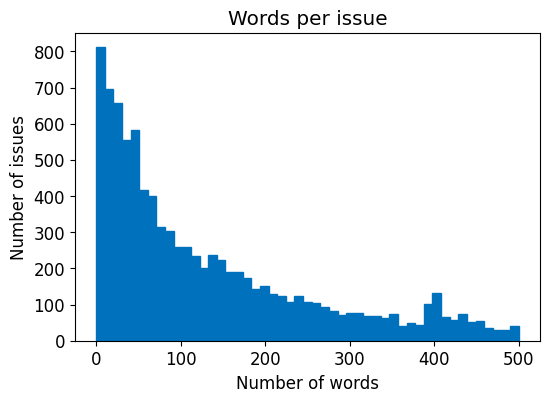

In [23]:
# Análisis exploratorio de los datos:
# "Cómo de largo son los issues"

import numpy as np # Para generar los intervalos (bins) del histograma
import matplotlib.pyplot as plt # Para dibujar la gráfica

(df_issues["text"].str.split().apply(len)
 .hist(bins=np.linspace(0, 500, 50), grid=False, edgecolor="C0"))

# .str.split() -> Separa el texto en palabras -> lista de palabras
# .apply(len) -> Aplica la función len() -> cuenta las palabras de la lista
# .hist() -> Crea un histograma
# np.linspace(0, 500, 50) -> Crea 50 números entre 0 y 500
plt.title("Words per issue")
plt.xlabel("Number of words")
plt.ylabel("Number of issues")
plt.show()

### Creating Training Sets

In [24]:
# Recordemos lo que es all_labels
all_labels

['tokenization',
 'new model',
 'model training',
 'usage',
 'pipeline',
 'tensorflow or tf',
 'pytorch',
 'examples',
 'documentation']

In [25]:
# convertimos las etiquetas de texto en un formato que un modelo de machine learning 
# pueda entender.

from sklearn.preprocessing import MultiLabelBinarizer

# MultiLabelBinarizer -> Clase especializada en problemas multietiquetas

mlb = MultiLabelBinarizer()

# entrenamos la clase
mlb.fit([all_labels])
# [all_labels] -> Porque fit() espera una lista de ejemplos, y cada ejemplo es una lista de etiquetas.

mlb.transform([["tokenization", "new model"], ["pytorch"]])

# crea un vector de 0 y 1 
    # 0 -> etiqueta no está presente
    # 1 -> etiqueta sí está presente

array([[0, 0, 0, 1, 0, 0, 0, 1, 0],
       [0, 0, 0, 0, 0, 1, 0, 0, 0]])

In [26]:
# Dividir los datos en entrenamiento y test sin perder el equilibrio de las etiquetas.

from skmultilearn.model_selection import iterative_train_test_split
# objetivo: Su objetivo es mantener aproximadamente la misma proporción de cada etiqueta 
# en ambos conjuntos (train y test)

def balanced_split(df, test_size=0.5): #recibe un DF y el % destdo a test:50% train/50%test
    ind = np.expand_dims(np.arange(len(df)), axis=1) 
    # genera los índices
    # ampliamos una dimensión Porque iterative_train_test_split espera matrices de 2 dim
    # axis=1 -> amplía por el lado de la columna: Pasamos de (5,) a (5,1)
    
    labels = mlb.transform(df["labels"])
    # Transforma para cada issue la columna labels que pasa a una matriz de ceros y unos
    
    ind_train, _, ind_test, _ = iterative_train_test_split(ind, labels, 
                                                           test_size)

    # recibe los índices "ind" y las etiquetas binarias "labels"
    # ind_train, _, ind_test, _  Recibimos 4 variables que corresponden a:
        # X_train
        # y_train
        # X_test
        #y_test
    # "_" -> No me interesa

    


    
    return df.iloc[ind_train[:, 0]], df.iloc[ind_test[:,0]]
    # Recuperamos las filas originales separadas por traion y test

In [27]:
# Separamos los datos entre datasets etiquetas y no etiquetados
# Después creamos sets de training, test y validación balaceados con balanced_split()

from sklearn.model_selection import train_test_split

# A) Crea una copia limpia

df_clean = df_issues[["text", "labels", "split"]].reset_index(drop=True).copy()
# crea una copia limpia del dataframe, sólo con las columnas text, labels y split
# .reset_index(drop=True) -> elimina el índice anterior (drop=True) y lo resetea
# .copy() -> "Quiero un DataFrame completamente independiente."


# B) Separar datos no etiquetados

df_unsup = df_clean.loc[df_clean["split"] == "unlabeled", ["text", "labels"]]
    # Conserva sólo las columnas "text" y "labels", filtrando las filas por aquellas en las 
    # que split= "unlabeled"
df_sup = df_clean.loc[df_clean["split"] == "labeled", ["text", "labels"]]
    # Conserva sólo las columnas "text" y "labels", filtrando las filas por aquellas en las 
    # que split= "labeled"

np.random.seed(0)

# Primera división: train y conjunto temporal a partir de df_sup: 50% Train

df_train, df_tmp = balanced_split(df_sup, test_size=0.5) 

#Segunda división: valid y test a partir del conjutno temporal: 25% Validación 25% Test

df_valid, df_test = balanced_split(df_tmp, test_size=0.5)

# Se hace esto porque balanced_split() devuelve únicamente dos conjuntos.

In [28]:
# Aquí dejamos de usar dataset de pandas y los convertimos en
# formato datasets de HF

from datasets import Dataset, DatasetDict

# Crea un DataserDict -> Empezamos a crear el diccionario con 4 claves
# train,valid, test (para lo etiquetado) y unsup para lo no etiquetado
# mete los no etiquetados "unsup" porque los usarán después y quieren que tenga el mismo formato

ds = DatasetDict({
    "train": Dataset.from_pandas(df_train.reset_index(drop=True)),# convertimos a ds de HF, reseteando índices
    "valid": Dataset.from_pandas(df_valid.reset_index(drop=True)),
    "test": Dataset.from_pandas(df_test.reset_index(drop=True)),
    "unsup": Dataset.from_pandas(df_unsup.reset_index(drop=True))})


### Creating Training Slices

In [29]:
# Queremos estudiar cómo cambia el rendimiento cuando se incrementa el número
# de ejemplos etiquetados.
# Este bloque crea subconjuntos acumulativos y estratificados del conjunto de entrenamiento.
# Se crearán conjuntos de tamaño:
# 8, 16, 32, 64, 128 y finalmente el conjunto completo

np.random.seed(0)

all_indices = np.expand_dims(list(range(len(ds["train"]))), axis=1)
# creamos los índices de todos los ejemplos del conjunto de entrenamiento
# expand_dims(..., axis=1) los convierte en una matriz columna (shape = (n,1)),
# ya que iterative_train_test_split()espera que X sea bidimensional.

indices_pool = all_indices
# Contendrá los índices que todavía no han sido seleccionados
# Al principio, todos los ejemplos están disponibles para ser seleccionados.
# Después de la primera llamada: 
    #indices_pool cambia automáticamente y pasa a contener solo los ejemplos que 
    # aún no se han usado.

labels = mlb.transform(ds["train"]["labels"])
# Convierte las etiquetas de texto en una matriz binaria (0 y 1) para que
# iterative_train_test_split() pueda mantener aproximadamente la distribución
# de todas las etiquetas en cada subconjunto.
# recordemos que antes  entrenamos la clase -> mlb.fit([all_labels])

train_samples = [8, 16, 32, 64, 128] #Tamaños de los conjuntos de entrenam q quiero probar

train_slices = [] 
last_k = 0
# train_slices almacenará los índices de cada subconjunto. -> lista vacía
# last_k recuerda el tamaño del subconjunto anterior-> Inicializamos variable en cero


for i, k in enumerate(train_samples):
    # i-> nº de iteración -> 0, 1, 2...
    # k -> tamaño del subconjunto en esa iteración -> 8, 16, 32...
    
    # Split off samples necessary to fill the gap to the next split size
    indices_pool, labels, new_slice, _ = iterative_train_test_split(
        indices_pool, labels, (k-last_k)/len(labels))
    last_k = k
    
    # Recordemos que esta función devuelve: 
        # X_train -> indices_pool, -> Lo necesito para seguir extrayendo ejemplos
        # y_train -> labels, -> etiquetas de los ejemplos que quedan en indices_pool.
            # debn seguir alineadas con indices_pool
        # X_test -> new_slice, 
        # y_tests -> _ -> No interesa pq X_test /new_slice sólo contiene índices
            # estos índices permiten recuperar las etiquetas cuando las necesiten
            # usando new_slice sobre ds["train"]
    # (k-last_k)/len(labels): Quiero extraer exactamente los ejemplos que faltan para pasar 
    # del subconjunto anterior al siguiente.
    # después de cada iteración-> labels: etiquetas de los ejemplos que no han sido seleccdos
    # Recordemos: iterative_train_test_split(ind, labels, test_size)
    
    if i==0: train_slices.append(new_slice)
    else: train_slices.append(np.concatenate((train_slices[-1], new_slice)))
        
# Add full dataset as last slice
train_slices.append(all_indices) 
# añade todos los índices de todos los ejemplos a train_slices
# Estructura de train_slice -> Lista de arrays de índices
#train_slices = [
#    array([ ... 8 índices ... ]),
#    array([ ... 16 índices ... ]),
#    array([ ... 32 índices ... ]),
#    array([ ... 64 índices ... ]),
#    array([ ... 128 índices ... ]), -> Teníamos hasta aquí
#    array([ ... todos los índices ... ]) -> Añadimos todos los índices



train_samples.append(len(ds["train"]))
# hace lo mismo con train_samples
# ambas listas están sincronizadas
# pasa de:
# [8, 16, 32, 64, 128] a [8, 16, 32, 64, 128, n]

train_slices = [np.squeeze(train_slice) for train_slice in train_slices]
# np.squeeze(train_slice) -> elimina la dimensión extra de antes.
# pasamos de (n,1) a (n,)

Lo importante es que te quedes con estas cuatro ideas:

- No crean datasets nuevos, crean listas de índices.

- Esos índices forman subconjuntos acumulativos:

8 ⊂ 16 ⊂ 32 ⊂ 64 ⊂ 128 ⊂ conjunto completo

- iterative_train_test_split() se utiliza para que cada subconjunto conserve aproximadamente la distribución de las etiquetas.
- Más adelante usarán esos índices para entrenar el mismo clasificador con diferentes cantidades de datos y comparar su rendimiento.

In [30]:
print("Target split sizes:")
print(train_samples)
print("Actual split sizes:")
print([len(x) for x in train_slices])

Target split sizes:
[8, 16, 32, 64, 128, 223]
Actual split sizes:
[10, 19, 36, 68, 134, 223]


Es una consecuencia de utilizar `iterative_train_test_split()`

Esta función no intenta respetar exactamente el número de ejemplos, sino mantener el equilibrio de las etiquetas (iterative stratification).

## Implementing a Naive Bayesline

## Conversión de etiquetas múltiples a un vector binario

Naive Bayes no soporta directamente clasificación **multietiqueta**.

Por eso se crea una nueva columna llamada:

```text
label_ids
```

En lugar de almacenar una lista de etiquetas:

```python
["pytorch", "documentation"]
```

se utiliza `MultiLabelBinarizer` (`mlb`) para convertirlas en un vector binario.

Por ejemplo:

```python
["pytorch", "documentation"]
```

↓

```text
[0 1 0 0 1 0 0 0 0]
```

Cada posición del vector representa una etiqueta distinta.

- **1** → la etiqueta está presente.
- **0** → la etiqueta no está presente.

---

## Transformación

```text
Lista de etiquetas
        │
        ▼
MultiLabelBinarizer
        │
        ▼
Vector binario
```

---

## Ejemplo

Supongamos que el conjunto de etiquetas es:

```text
[
    "bug",
    "documentation",
    "feature",
    "pytorch",
    "tokenization"
]
```

Entonces:

```python
["pytorch", "documentation"]
```

se transforma en:

```text
[0 1 0 1 0]
```

porque:

| Etiqueta | Valor |
|----------|:-----:|
| bug | 0 |
| documentation | 1 |
| feature | 0 |
| pytorch | 1 |
| tokenization | 0 |

---

## Estructura del DataFrame

Después de la transformación tendremos tres columnas principales:

| text | labels | label_ids |
|------|--------|-----------|
| Texto de la incidencia | `["bug"]` | `[1 0 0 0 0]` |
| Texto de la incidencia | `["pytorch", "documentation"]` | `[0 1 0 1 0]` |
| Texto de la incidencia | `["feature"]` | `[0 0 1 0 0]` |

---

## Flujo completo

```text
text
labels
        │
        ▼
MultiLabelBinarizer
        │
        ▼
label_ids
        │
        ▼
DataFrame

text
labels
label_ids
```

La columna `labels` conserva los nombres originales de las etiquetas, mientras que `label_ids` contiene su representación binaria, que es la que utilizarán posteriormente los modelos de Machine Learning.

In [31]:
#hide_output
def prepare_labels(batch):
    batch["label_ids"] = mlb.transform(batch["labels"])
    return batch

ds = ds.map(prepare_labels, batched=True)
# aplica función a todo el dataset

Map:   0%|          | 0/223 [00:00<?, ? examples/s]

Map:   0%|          | 0/106 [00:00<?, ? examples/s]

Map:   0%|          | 0/111 [00:00<?, ? examples/s]

Map:   0%|          | 0/9303 [00:00<?, ? examples/s]

In [32]:
from collections import defaultdict

macro_scores = defaultdict(list) # guardará  puntuaciones macro F1 
micro_scores = defaultdict(list) # guardará  puntuaciones micro F1

# creamos 2 defaultdict() -> diccionario inteligente. Si una clave no existe -> la crea.


In [33]:
# Para borrar resultados del siguiente entrenamiento
macro_scores["Naive Bayes"] = []
micro_scores["Naive Bayes"] = []

In [34]:
from sklearn.naive_bayes import MultinomialNB 
# Importa el clasificador Naive Baye

from sklearn.metrics import classification_report 
#Calcula todas las métricas de clasificación:
    # precisión
    # recall
    # f1
    # support

from skmultilearn.problem_transform import BinaryRelevance
# Naive Bayes no soporta clasificación multietiqueta.
# Binary Relevance transforma el problema en varios problemas binarios independientes
    #¿Es "pytorch"?          Sí/No
    #¿Es "documentation"?    Sí/No
    #¿Es "pipeline"?         Sí/No
# Si hay 9 etiquetas, realmente entrenará 9 Naive Bayes distintos.

from sklearn.feature_extraction.text import CountVectorizer
# Convierte texto en números

for train_slice in train_slices:
    
    # Get training slice and test data
    ds_train_sample = ds["train"].select(train_slice) 
    # selecciona el conjunto de entrenamiento, elgiendo cada train_slice
    # ds_train_sample -> onbjeto de HF -> devuelve: datasets.arrow_dataset.Dataset
    y_train = np.array(ds_train_sample["label_ids"])
    # ds_train_sample["label_ids"] -> devuelve una lista de listas python.
    # Lo pasamos np.array porque scikit-leab traba internamnete ciob matrices de Numpy
    y_test = np.array(ds["test"]["label_ids"])
    # hacemos lo mismo con test
    
    # Use a simple count vectorizer to encode our texts as token counts
    count_vect = CountVectorizer()
    # creamos el vectorizador
    
    X_train_counts = count_vect.fit_transform(ds_train_sample["text"])
    # Se hacen 2 cosas:
        # fit-> aprende el vocabulario
        # transform -> convierte cada texto en un vector de frecuencia
        
    X_test_counts = count_vect.transform(ds["test"]["text"])
    # Para test mo usamos .fit porque el vocab aprendido debe ser el mismo que en train
    
    # Create and train our model!
    classifier = BinaryRelevance(classifier=MultinomialNB())
    # Creamos el clasificador BinaryRelevance -> entrena un Naive Bayes para cada etiqueta
    # elegimos el MiltinomialNB
    
    classifier.fit(X_train_counts, y_train)
    # aquí aprende la clasificación: pasamos x e y (etiquetas)
    
    
    # Generate predictions and evaluate
    
    y_pred_test = classifier.predict(X_test_counts)
    # predecimos pasando las x de test
    
    clf_report = classification_report(
        y_test, y_pred_test, target_names=mlb.classes_, zero_division=0,
        output_dict=True)

    # compara predicción vs etiqueta real
    # output_dict=True -> resultados en un diccionario
    # target_names=mlb.classes_ -> le pasamos el nombre de cada columna  de la matriz  binaria de mlb
    # zero_division=0. Este parámetro evita errores cuando aparece una división entre cero
    # en lugar de lanzar errores -> devuelve resultado=0
    
    # Store metrics /guardamos métricas
    macro_scores["Naive Bayes"].append(clf_report["macro avg"]["f1-score"])
    micro_scores["Naive Bayes"].append(clf_report["micro avg"]["f1-score"])

In [35]:
# Esta función dibuja los resultados que se han ido almacenando en:
    # micro_scores
    # macro_scores

import matplotlib.pyplot as plt

def plot_metrics(micro_scores, macro_scores, sample_sizes, current_model):
    fig, (ax0, ax1) = plt.subplots(1, 2, figsize=(10, 4), sharey=True)
    # crea la figura -> dos gráficos (1 fila 2 columnas). 
    # comparten y

    for run in micro_scores.keys():
        # recorre el diccionario. Por ejemplo:
       # {
       # "Naive Bayes": [...],
       # "Logistic Regression": [...],
       # "BERT": [...]
       # }

        
        if run == current_model: # Destacamos el modelo actual
            ax0.plot(sample_sizes, micro_scores[run], label=run, linewidth=2)# línea + gruesa
            ax1.plot(sample_sizes, macro_scores[run], label=run, linewidth=2)
        else:
            ax0.plot(sample_sizes, micro_scores[run], label=run, 
                     linestyle="dashed")
            ax1.plot(sample_sizes, macro_scores[run], label=run, 
                     linestyle="dashed")

    ax0.set_title("Micro F1 scores")
    ax1.set_title("Macro F1 scores")
    ax0.set_ylabel("Test set F1 score")
    ax0.legend(loc="lower right")
    for ax in [ax0, ax1]:
        ax.set_xlabel("Number of training samples")
        ax.set_xscale("log") # como no están igualmente espaciados -> con escala logarítimica 
                             # están mejor espaciado
        ax.set_xticks(sample_sizes) # las marcas estrán excatamnete en 10, 19...
        ax.set_xticklabels(sample_sizes)
        ax.minorticks_off() # quita pequeñas subdiviones del eje
    plt.tight_layout()
    plt.show()

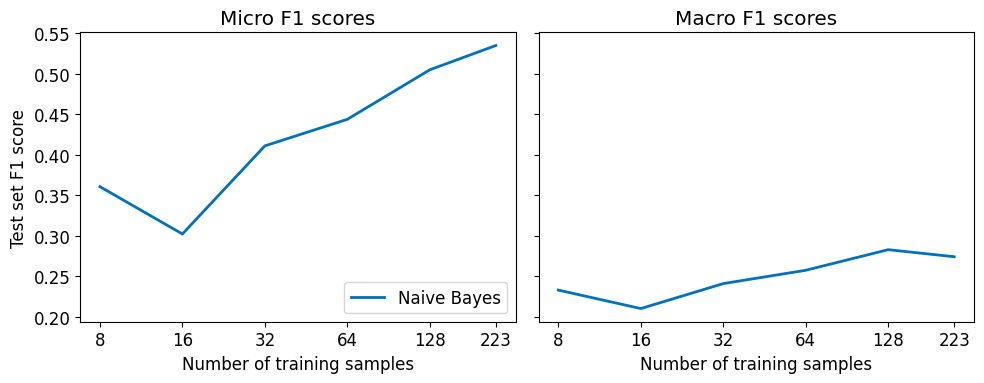

In [36]:
plot_metrics(micro_scores, macro_scores, train_samples, "Naive Bayes")

## Macro F1 vs Micro F1

### Macro F1

Se calcula el **F1 de cada etiqueta por separado** y, posteriormente, se obtiene la media de todos ellos.

Características:

- Cada etiqueta tiene el mismo peso.
- No importa si una etiqueta aparece miles de veces o solo unas pocas.

```text
Etiqueta 1 ──► F1₁
Etiqueta 2 ──► F1₂
Etiqueta 3 ──► F1₃
      ...
Etiqueta n ──► F1ₙ
                  │
                  ▼
      Media de todos los F1
```

---

### Micro F1

En lugar de calcular un F1 para cada etiqueta, primero se suman todos los aciertos y errores de todas las etiquetas.

Es decir, se agregan:

- Todos los **True Positives (TP)**.
- Todos los **False Positives (FP)**.
- Todos los **False Negatives (FN)**.

Después se calcula un único valor de F1.

```text
Todas las etiquetas
        │
        ▼
Sumar todos los:

TP
FP
FN
        │
        ▼
Calcular un único F1
```

---

## ¿Cuál es mejor?

Depende del objetivo.

### Si todas las etiquetas son igual de importantes

→ **Macro F1**

Porque trata todas las etiquetas por igual y penaliza mucho un mal rendimiento en etiquetas poco frecuentes.

---

### Si importa el rendimiento global del modelo

→ **Micro F1**

Porque refleja el comportamiento conjunto sobre todas las predicciones realizadas.

---

## Comparación

| Métrica | ¿Cómo se calcula? | ¿Cuándo utilizarla? |
|----------|-------------------|---------------------|
| **Macro F1** | Calcula el F1 de cada etiqueta y obtiene la media. | Cuando todas las etiquetas tienen la misma importancia, incluidas las raras. |
| **Micro F1** | Suma todos los TP, FP y FN y calcula un único F1. | Cuando interesa medir el rendimiento global del modelo. |

---

## Esquema conceptual

```text
Macro F1

Etiqueta 1 ──► F1
Etiqueta 2 ──► F1
Etiqueta 3 ──► F1
      ...
        │
        ▼
Media
```

```text
Micro F1

Todas las etiquetas
        │
        ▼
Sumar TP + FP + FN
        │
        ▼
Calcular un único F1
```




## Working with No Labeled Data

In [37]:
#hide_output
from transformers import pipeline

pipe = pipeline("fill-mask", model="bert-base-uncased")

In [38]:
movie_desc = "The main characters of the movie madacascar \
are a lion, a zebra, a giraffe, and a hippo. "
prompt = "The movie is about [MASK]."

output = pipe(movie_desc + prompt)
for element in output:
    print(f"Token {element['token_str']}:\t{element['score']:.3f}%")

Token animals:  0.103%
Token lions:    0.066%
Token birds:    0.025%
Token love:     0.015%
Token hunting:  0.013%


en este ejemplo BERT solo predice un token, porque el prompt contiene una única máscara.

Hay un solo [MASK]


In [39]:
# Tb podemos pasarle al modelo algunos tokens objetivo para que calcule su probabilidad
output = pipe(movie_desc + prompt, targets=["animals", "cars"])
for element in output:
    print(f"Token {element['token_str']}:\t{element['score']:.3f}%")

Token animals:  0.103%
Token cars:     0.001%


In [40]:
movie_desc = "In the movie transformers aliens \
can morph into a wide range of vehicles."

output = pipe(movie_desc + prompt, targets=["animals", "cars"])
for element in output:
    print(f"Token {element['token_str']}:\t{element['score']:.3f}%")

Token cars:     0.139%
Token animals:  0.006%


In [41]:
# Modelo MNLI para zero-shot classification en Transformers 
from transformers import pipeline

pipe = pipeline("zero-shot-classification", device=0)
# device = 0 -> GPU número 0
# Se descarga un modelo BART entrenado sobre MNLI
# Podríamos haber puesto:
    #pipe = pipeline(
    #"zero-shot-classification",
    #model="facebook/bart-large-mnli",
    #device=0
    #                )

In [42]:
# Para saber el modelo que he descargado
print(pipe.model.name_or_path)

facebook/bart-large-mnli


In [43]:
# Primer ejemplo de Zero-Shot Classification

sample = ds["train"][0] # primer ejemplo del DataSet
# será un diccionario parecido a:
#{
#    "text": "...",
#    "labels": ["pytorch", "documentation"],
#    "label_ids": [0,0,0,0,0,1,0,0,1]
#}



print(f"Labels: {sample['labels']}") # mostramos las etiquetas reales

output = pipe(sample["text"], all_labels, multi_label=True)

# Le pasamos
    # sample["text"] -> el texto -> la incidencia completa
    #  all_labels -> Todas las etiquetas posibles. Recordemos que all_labels es:

        #['tokenization',
        # 'new model',
        # 'model training',
        # 'usage',
        # 'pipeline',
        # 'tensorflow or tf',
        # 'pytorch',
        # 'examples',
        # 'documentation']
    # multi_label=True -> El texto puede pertenecer a varias categorías al mismo tiempo.
    # internamente calcula una hipótesis para cada etiqueta
        #This example is about tokenization.-> calcula entailment
        #This example is about new model.-> calcula entailment
        #...


print(output["sequence"][:400]) 
# Imprime los primeros 400 caracteres del texto. 
# Solo para recordar qué documento se está clasificando.



# Mostramos las predicciones:

print("\nPredictions:")

for label, score in zip(output["labels"], output["scores"]):
    print(f"{label}, {score:.2f}")

Labels: ['new model']
Add new CANINE model

# 🌟 New model addition

## Model description

Google recently proposed a new **C**haracter **A**rchitecture with **N**o
tokenization **I**n **N**eural **E**ncoders architecture (CANINE). Not only the
title is exciting:

> Pipelined NLP systems have largely been superseded by end-to-end neural
modeling, yet nearly all commonly-used models still require an explicit tokeni

Predictions:
new model, 0.98
tensorflow or tf, 0.37
examples, 0.34
usage, 0.30
pytorch, 0.25
documentation, 0.25
model training, 0.24
tokenization, 0.17
pipeline, 0.16


In [44]:
# hide_output
# Aplicamos el clasificador Zero-Shot a todos los ejemplos del conjunto de validación.

def zero_shot_pipeline(example):
    output = pipe(example["text"], all_labels, multi_label=True)
    example["predicted_labels"] = output["labels"]
    # guardamos etiquetas predichas añadiendo una columna
    example["scores"] = output["scores"]
    # guardamos puntuaciones predichas añadiendo una columna
    return example # devuelve el ejemplo
    # los ejemplos del dataset tendrán ahora esta estructura:
         #{   
         #   "text": "...",
         #   "labels": [...],
         #   "predicted_labels": [...],
         #   "scores": [...]
         #}


# Aplicamos la función al dataset de validación ( ds["valid") con map()
ds_zero_shot = ds["valid"].map(zero_shot_pipeline)

# Dataset.map() hace algo parecido a esto:

# resultado = []

# for example in ds["valid"]:
#    resultado.append(
#        zero_shot_pipeline(example)
#    )

Map:   0%|          | 0/106 [00:00<?, ? examples/s]

In [45]:
# Este bloque sirve para convertir las predicciones del modelo en el mismo formato 
# que las etiquetas reales, de forma que luego puedan calcular métricas como el F1.

def get_preds(example, threshold=None, topk=None):
    preds = [] # Aquí iremos guardando las etiquetas finales que aceptemos.
    if threshold: # si usamos umbral
        for label, score in zip(example["predicted_labels"], example["scores"]):
            if score >= threshold: # si puntuación supera el umbral -> preds
                preds.append(label)
    elif topk: # si usamos las k mejores ( en HF ordenado de mayor a menor puntuación)
        for i in range(topk):
            preds.append(example["predicted_labels"][i])
    else: # si no indicamos ninguno;
        raise ValueError("Set either `threshold` or `topk`.") #Obliga al usuario a elegir una estrategia.
    return {"pred_label_ids": list(np.squeeze(mlb.transform([preds])))}
    # mlb.transform([preds])->transforma en una lista de vectores binarios
    # np.squeeze() -> elimina la dimensión sobrante
    # list() convierte de numpy.array a lista normal de Python
    # Porque las verdaderas tiquetas (label_ids) ya tienen ese formato.

In [46]:
# Envuelve una llamada a classification_report() 
# para no tener que repetir el mismo código cada vez.

def get_clf_report(ds):
    y_true = np.array(ds["label_ids"]) # etiquetas reales
    y_pred = np.array(ds["pred_label_ids"]) # etiquetas predichas 
    return classification_report(
        y_true, y_pred, target_names=mlb.classes_, zero_division=0, 
        output_dict=True)

In [47]:
#hide_output

# Método top-k

# ¿Qué pasa si obligo al modelo a devolver exactamente 1, 2, 3 o 4 etiquetas?
macros, micros = [], []
topks = [1, 2, 3, 4]
for topk in topks:
    ds_zero_shot = ds_zero_shot.map(get_preds, batched=False,
                                    fn_kwargs={'topk': topk})
    clf_report = get_clf_report(ds_zero_shot)
    micros.append(clf_report['micro avg']['f1-score'])
    macros.append(clf_report['macro avg']['f1-score'])

Map:   0%|          | 0/106 [00:00<?, ? examples/s]

Map:   0%|          | 0/106 [00:00<?, ? examples/s]

Map:   0%|          | 0/106 [00:00<?, ? examples/s]

Map:   0%|          | 0/106 [00:00<?, ? examples/s]

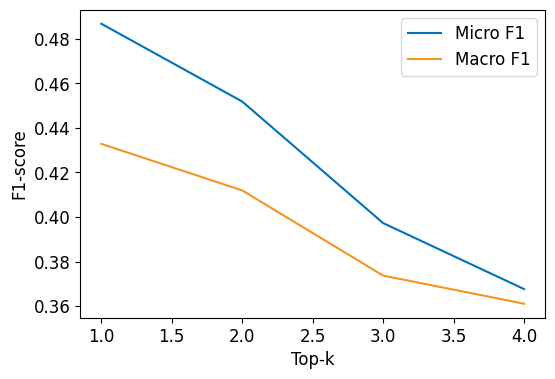

In [48]:
plt.plot(topks, micros, label='Micro F1')
plt.plot(topks, macros, label='Macro F1')
plt.xlabel("Top-k")
plt.ylabel("F1-score")
plt.legend(loc='best')
plt.show()

El mejor resultado se obtiene prediciendo únicamente la etiqueta más probable (topk=1).
Porque con 1 no hay falsos positivos pero con 4 predicciones hay un match y tres falsos postivos.

Porque sólo tenemos uan etiqueta real

In [49]:
#hide_output

# Método del umbral

# ¿Qué nivel de confianza le exijo al modelo para aceptar una etiqueta?
macros, micros = [], []
thresholds = np.linspace(0.01, 1, 100) # generamos 100 umbrales de 0.01 a 1
for threshold in thresholds:
    ds_zero_shot = ds_zero_shot.map(get_preds,
                                    fn_kwargs={"threshold": threshold})
    clf_report = get_clf_report(ds_zero_shot)
    micros.append(clf_report["micro avg"]["f1-score"])
    macros.append(clf_report["macro avg"]["f1-score"])

Map:   0%|          | 0/106 [00:00<?, ? examples/s]

Map:   0%|          | 0/106 [00:00<?, ? examples/s]

Map:   0%|          | 0/106 [00:00<?, ? examples/s]

Map:   0%|          | 0/106 [00:00<?, ? examples/s]

Map:   0%|          | 0/106 [00:00<?, ? examples/s]

...

Map:   0%|          | 0/106 [00:00<?, ? examples/s]

Map:   0%|          | 0/106 [00:00<?, ? examples/s]

Map:   0%|          | 0/106 [00:00<?, ? examples/s]

Map:   0%|          | 0/106 [00:00<?, ? examples/s]

Map:   0%|          | 0/106 [00:00<?, ? examples/s]

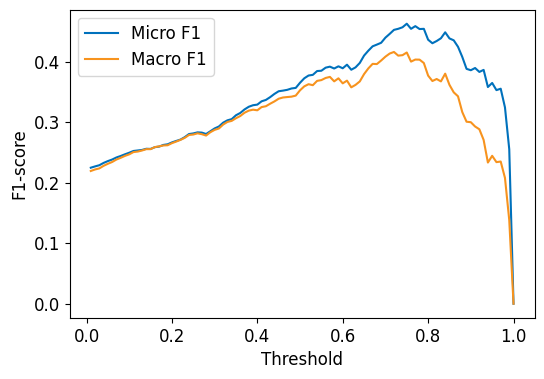

In [50]:
plt.plot(thresholds, micros, label="Micro F1")
plt.plot(thresholds, macros, label="Macro F1")
plt.xlabel("Threshold")
plt.ylabel("F1-score")
plt.legend(loc="best")
plt.show()

In [51]:
# buscamos automáticamente el mejor umbral
best_t = thresholds[np.argmax(micros)]
best_micro = np.max(micros)
#Importante: argmax devuelve el índice, no el valor.
# thresholds[np.argmax(micros)] -> obtenemos el mayor valor

print(f'Best threshold (micro): {best_t} with F1-score {best_micro:.2f}.')

best_t = thresholds[np.argmax(macros)]
best_macro = np.max(macros)

print(f'Best threshold (macro): {best_t} with F1-score {best_macro:.2f}.')

Best threshold (micro): 0.75 with F1-score 0.46.
Best threshold (macro): 0.72 with F1-score 0.42.


In [52]:
#hide_output
ds_zero_shot = ds['test'].map(zero_shot_pipeline)
# Aplica el clasificador zero-shot a todo el conjunto de test y añade
    # predicted_labels
    # scores
ds_zero_shot = ds_zero_shot.map(get_preds, fn_kwargs={'topk': 1})
# Convierte esas predicciones en formato binario usando solo la etiqueta mejor posicionada

clf_report = get_clf_report(ds_zero_shot)
# Compara:label_ids reales vs.pred_label_ids predichos
# Obtiene el macro F1 y micro F1

for train_slice in train_slices:
    macro_scores['Zero Shot'].append(clf_report['macro avg']['f1-score'])
    micro_scores['Zero Shot'].append(clf_report['micro avg']['f1-score'])

Map:   0%|          | 0/111 [00:00<?, ? examples/s]

Map:   0%|          | 0/111 [00:00<?, ? examples/s]

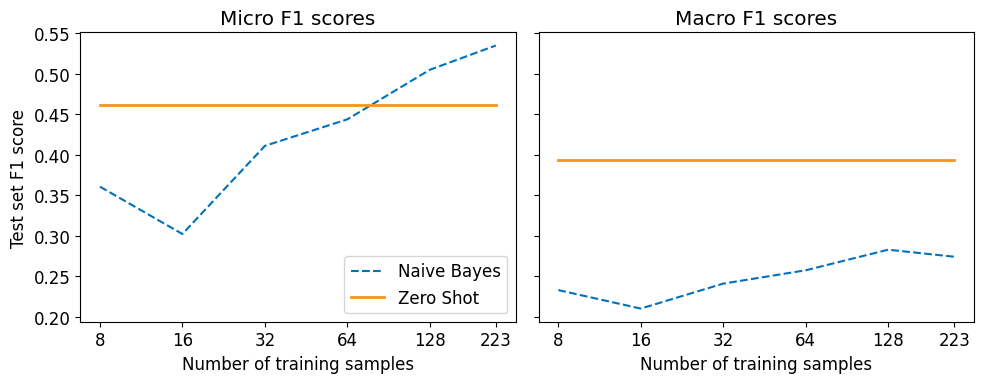

In [53]:
plot_metrics(micro_scores, macro_scores, train_samples, "Zero Shot")

In [54]:
# Para ver las etiquetas que genera Naive Bayes y Zero- Shot

sample = ds["test"][0]

print("Etiquetas reales:")
print(sample["labels"])

print("\nNaive Bayes:")
print(mlb.inverse_transform(y_pred_test[:1]))

print("\nZero-Shot:")
output = pipe(sample["text"], all_labels, multi_label=True)
for label, score in zip(output["labels"], output["scores"]):
    print(f"{label:20} {score:.3f}") # 20 caracteres para imprimir label

Etiquetas reales:
['new model']

Naive Bayes:
[('new model',)]

Zero-Shot:
new model            0.998
model training       0.753
documentation        0.593
pipeline             0.491
tensorflow or tf     0.361
usage                0.311
examples             0.286
pytorch              0.277
tokenization         0.218


## Working with a Few Labels

### Data Augmentation

In [55]:
#hide
# Este bloque compara cinco técnicas de data augmentation sobre una misma frase. 
# La idea es generar versiones ligeramente distintas que, idealmente, 
# conserven el significado y la misma etiqueta.

from transformers import set_seed

# Importamos distintos grupos de aumentadores nlpaug:
import nlpaug.augmenter.word as naw # transformaciones a nivel de palabra. Usamos éste.
import nlpaug.augmenter.char as nac # transformaciones a nivel de carácter
import nlpaug.augmenter.sentence as nas # transformaciones a nivel de oración.
import nlpaug.flow as nafc # permite combinar transformaciones en flujos.
import nltk # trabaja por debajo de nlpaug 

nltk.download('averaged_perceptron_tagger') # identifica categorías gramaticales.
nltk.download("averaged_perceptron_tagger_eng") # versión en inglés
nltk.download('wordnet') # proporciona sinónimos y relaciones léxicas.
nltk.download('omw-1.4') # amplía WordNet con recursos multilingües.

set_seed(3)

text = "Even if you defeat me Megatron, others will rise to defeat your tyranny"
augs = {} # diccionario vacío donde:
    # clave: describe la técnica
    # valor: objeto que realizará la transformación

augs["synonym_replace"] = naw.SynonymAug(aug_src='wordnet')
# Busca palabras sustituibles y las reemplaza por sinónimos de WordNet.

augs["random_insert"] = naw.ContextualWordEmbsAug(model_path="distilbert-base-uncased", 
                                device="cpu", action="insert", aug_max=1)
# Inserción contextual.
# Usa DistilBERT para insertar una palabra que resulte razonable según el contexto.
    # model_path: modelo usado para proponer la palabra.
    # device="cpu": lo ejecuta en CPU.
    # action="insert": inserta, no sustituye.
     #aug_max=1: inserta como máximo una palabra

augs["random_swap"] = naw.RandomWordAug(action="swap")
# Intercambio de palabras
# Intercambia aleatoriamente la posición de algunas palabras.

augs["random_delete"] = naw.RandomWordAug()
# Eliminación aleatoria.
# Como no indicas action, RandomWordAug usa su acción predeterminada, 
# que es eliminar palabras.

augs["bt_en_de"] = naw.BackTranslationAug(
    from_model_name='facebook/wmt19-en-de', 
    to_model_name='facebook/wmt19-de-en'
)
# Retrotraducción
# Hace el recorrido inglés → alemán → inglés


for k,v in augs.items():
    print(f"Original text: {text}")
    print(f"{k}: {v.augment(text)}")
    print("")
# Para cada técnica:
    # imprime el texto original;
    # genera una variante con v.augment(text);
    # imprime una línea en blanco.


[nltk_data] Downloading package averaged_perceptron_tagger to
[nltk_data]     /home/srmjf/nltk_data...
[nltk_data]   Package averaged_perceptron_tagger is already up-to-
[nltk_data]       date!
[nltk_data] Downloading package averaged_perceptron_tagger_eng to
[nltk_data]     /home/srmjf/nltk_data...
[nltk_data]   Package averaged_perceptron_tagger_eng is already up-to-
[nltk_data]       date!
[nltk_data] Downloading package wordnet to /home/srmjf/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to /home/srmjf/nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!


Original text: Even if you defeat me Megatron, others will rise to defeat your
tyranny
synonym_replace: ['Even if you vote down me Megatron, others will turn out to
defeat your tyranny']

Original text: Even if you defeat me Megatron, others will rise to defeat your
tyranny
random_insert: ['even if you defeat me megatron, others will rise to physically
defeat your tyranny']

Original text: Even if you defeat me Megatron, others will rise to defeat your
tyranny
random_swap: ['Even if you defeat Megatron me, others to will rise defeat your
tyranny']

Original text: Even if you defeat me Megatron, others will rise to defeat your
tyranny
random_delete: ['Even if me Megatron, will rise to tyranny']

Original text: Even if you defeat me Megatron, others will rise to defeat your
tyranny
bt_en_de: ['Even if you defeat me, Megatron, others will rise up to conquer your
tyranny, to defeat your tyranny, and I will not be defeated by you, and I will
be defeated by you, and I will be defeated by you

In [56]:
# En lugar de buscar un sinónimo en un diccionario (WordNet), 
# dejamos que DistilBERT decida qué palabra encaja mejor en el contexto.
# Para ello -> usa DistilBERT -> capaz de ebtender el contexto de una frase

from transformers import set_seed
import nlpaug.augmenter.word as naw

set_seed(3)
aug = naw.ContextualWordEmbsAug(model_path="distilbert-base-uncased", 
                                device="cpu", action="substitute")

# action="substitute" -> Sustituye una palabra existente por otra que tenga sentido en ese contexto.
# antes usamos action = "insert" -> Insertaba una palabra nueva
text = "Transformers are the most popular toys"
print(f"Original text: {text}")
print(f"Augmented text: {aug.augment(text)}")

Original text: Transformers are the most popular toys
Augmented text: ['transformers have the most available toys']


El objetivo es producir una frase suficientemente parecida para entrenar mejor al modelo.

In [57]:
# Función que recibe un lote de ejemplos y devuelve un lote + grande con ejemplos aumentados.

def augment_text(batch, transformations_per_example=1):
    text_aug, label_ids = [], [] # Creamos 2 listas
    
    # Añadimos texto original
    for text, labels in zip(batch["text"], batch["label_ids"]):
        text_aug += [text] # equivale a text_aug.append(text)
        label_ids += [labels] # label_ids.append(labels)
        
        # Generamos nuevas versiones
        for _ in range(transformations_per_example):
            text_aug += aug.augment(text) # generamos un nuevo texto
            label_ids += [labels] # copiamos la misma etiqueta porque el significado es el mismo
    return {"text": text_aug, "label_ids": label_ids} # devuelve un batch nuevo

    # No sustituye los ejemplos originales, sino que los conserva y añade los nuevos.

In [58]:
#hide
# Aquí se repite el entrenamiento de Naive Bayes, pero ahora 
# entrena con los textos originales más los textos aumentados
# comparación Naives Bayes Normal vs Naives Bayes + Data Augmentation

for train_slice in train_slices: # Recorre los tamaños de entrenamiento
    # Get training slice and test data
    # Vuelve a entrenar con cada subconjunto acumulativo:
    # ≈10, 19, 36, 68, 134 y 223 ejemplos originales
    
    ds_train_sample = ds["train"].select(train_slice) 
    # selecciona el subconjunto original-> 1ª iter: 10 ejemplos reales
    
    # Flatten augmentations and align labels!
    ds_train_aug = (ds_train_sample.map(
        augment_text, batched=True, remove_columns=ds_train_sample.column_names)
                    .shuffle(seed=42))
    # aplica el aumento de datos
    # remove_columns=ds_train_sample.column_names -> elimina columnas antiguas.
    # Nos quedaremos con las que produce augment_text() -> "text" y "label_ids"
    #.shuffle() -> antes: original1, aumentado1 ,original2, aumentado2...
    # esto lo mezcla

    
    y_train = np.array(ds_train_aug["label_ids"])
    y_test = np.array(ds["test"]["label_ids"]) 
    # el test ni se aumenta ni se modifica
    # augmentation sólo en entrenamiento
    # Use a simple count vectorizer to encode our texts as token counts
    
    count_vect = CountVectorizer()
    
    X_train_counts = count_vect.fit_transform(ds_train_aug["text"])
    X_test_counts = count_vect.transform(ds["test"]["text"])
   # Crea el vocabulario con los datos aumentados
    
    # Create and train our model!
    classifier = BinaryRelevance(classifier=MultinomialNB())
    classifier.fit(X_train_counts, y_train)
    # entrena nuevamnete Naive Bayes -> Lo único diferente son los datos de entrenamiento
    
    
    # Generate predictions and evaluate
    y_pred_test = classifier.predict(X_test_counts)
    # Predecimos

    
    clf_report = classification_report(
        y_test, y_pred_test, target_names=mlb.classes_, zero_division=0,
        output_dict=True)
    # evaluamos
    
    # Store metrics
    macro_scores["Naive Bayes + Aug"].append(clf_report["macro avg"]["f1-score"])
    micro_scores["Naive Bayes + Aug"].append(clf_report["micro avg"]["f1-score"])

    # Guarda resultados con otro nombre

Map:   0%|          | 0/10 [00:00<?, ? examples/s]

Map:   0%|          | 0/19 [00:00<?, ? examples/s]

Map:   0%|          | 0/36 [00:00<?, ? examples/s]

Map:   0%|          | 0/68 [00:00<?, ? examples/s]

Map:   0%|          | 0/134 [00:00<?, ? examples/s]

Map:   0%|          | 0/223 [00:00<?, ? examples/s]

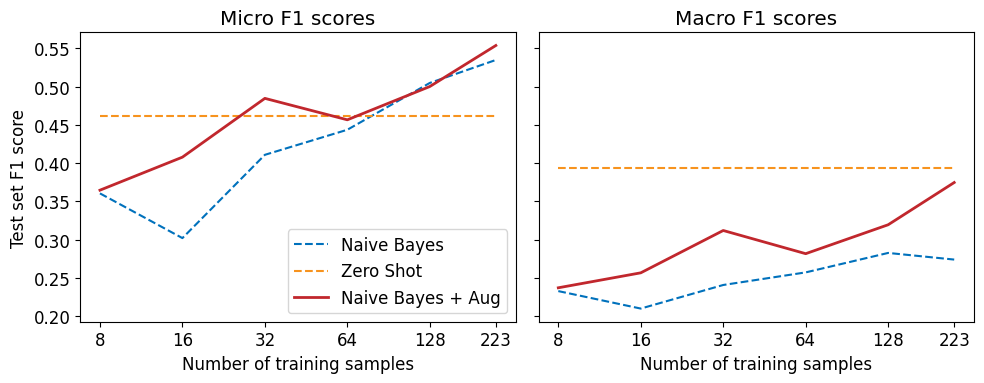

In [59]:
plot_metrics(micro_scores, macro_scores, train_samples, "Naive Bayes + Aug")

# Recordemos que def plot_metrics(micro_scores, macro_scores, sample_sizes, current_model)

Añadir ejemplos sintéticos ayuda casi siempre.

La línea naranja permanece constante.

¿Por qué?

Porque Zero-Shot:

no usa el conjunto de entrenamiento;
no aprende nada nuevo.

### Using Embeddings as a Lookup Table

<img alt="nearest-neighbours" caption="An illustration of nearest neighbor embedding lookup" src="images/chapter09_nearest-neighbours.png" id="nearest-neighbours"/>

In [60]:
# objetivo:convertir cada texto en un único vector (embedding) que luego servirá 
# para buscar textos similares

import torch
from transformers import AutoTokenizer, AutoModel



model_ckpt = "miguelvictor/python-gpt2-large"
tokenizer = AutoTokenizer.from_pretrained(model_ckpt)
model = AutoModel.from_pretrained(model_ckpt)
# cargamos el modelo
# No cargamos un clasificador (AutoModelForSequenceClassification), 
# sino únicamente el transformer (AutoModel)
# Porque sólo queremos los embeddings
# Automodel-> sólo devuelve el Transformer
# Automodel-> Texto -> Tokenizador -> Transformer -> n vectores de 1280 dimensiones
# Pero no tenemos un embedding de la frase


# Para convertir N x 1280 en 1 x1280:

def mean_pooling(model_output, attention_mask):
    # Extract the token embeddings
    token_embeddings = model_output[0] # extrae la matriz de embeddings
    
    # estructura
    # BaseModelOutput(
    # last_hidden_state=tensor(...),->Esto es lo q queremos. Shape batch_size, seq_len, hidden_size): ej (8, 35, 1280) Salida de la última capa del transformer: Últimos embeddings contextualizados
    # hidden_states=None,
    # attentions=None
    #   )

    
    # Compute the attention mask
    input_mask_expanded = (attention_mask
                           .unsqueeze(-1)
                           .expand(token_embeddings.size())
                           .float())

    # A tener en cuenta:
        # model_output = model(**inputs) -> desempaqueta el diccionario "inputs" 
        # y equivale a:
        # model(input_ids=inputs["input_ids"],attention_mask=inputs["attention_mask"])
    # Como luego queremos multiplicar token_embeddings (5,3) * attention mask (5,) y tienen
    # shape distinta:
        #1) .unsqueeze(-1) -> aumentamos una dimensión -> De (5,) a (5,1)
        #2) .expand(token_embeddings.size()) -> copia cada número tantas veces como dimensiones tenga el embedding
            # Pasamos de (5,1) a (5,3)
        #3) .float() -> pasamos a flotantes por token_embeddings son flotantes
    

    
    # Sum the embeddings, but ignore masked tokens
    sum_embeddings = torch.sum(token_embeddings * input_mask_expanded, 1)
    # Multiplicamos token_embeddings e input_mask -> las posiciones de [PAD] quedan en ceros
    # sumamos a lo largo de la dimensión 1
    # ojo! shape del producto (batch_size, nº_tokens, embedding_size) -> sumamos tokens en vertical
    
    
    sum_mask = torch.clamp(input_mask_expanded.sum(1), min=1e-9)
    # torch.clamp() -> asegura que si por lo que fuera el vector final resultante fuese menor que 1e-9,
    # daría un resultad de 1e-9 -> Para no dividir por cero
    
    # Return the average as a single vector
    return sum_embeddings / sum_mask
    # dividimos los embeddings por el número de tokens válidos (los 1's de la máscara)


# Esta función toma uno o varios textos y devuelve n embedding pot texto
def embed_text(examples):
    inputs = tokenizer(examples["text"], padding=True, truncation=True,
                       max_length=128, return_tensors="pt")
    # Convierte los textos en tensores. 
    # inputs contiene, como mínimo:
        # inputs["input_ids"]
        # inputs["attention_mask"]
    # padding=True -> iguala la longitud de los textos dentro del batch. 
    # truncation=True -> corta los que superen 128 tokens.
    
    with torch.no_grad(): # solo hacemos inferencia:no calculamos gradientes ni entrenamos el modelo.
        model_output = model(**inputs)
    pooled_embeds = mean_pooling(model_output, inputs["attention_mask"])
        # aplicamos la función de antes
        # pone a cero los embeddings de los tokens de padding;
        # suma los embeddings válidos;
        # cuenta cuántos tokens válidos hay;
        # divide la suma entre ese número.
        # Pasamos de (batch_size, sequence_length, hidden_size) a (batch_size, hidden_size)
    return {"embedding": pooled_embeds.cpu().numpy()}
    # devuelve un tensor pytorch -> pasamos a cpu y convertimos en array de numpy (sólo puede hacerse en CPU)

In [61]:
# hide_output
# precalcula los embeddings de todo el dataset.
# Problema: GPT-2 no fue entrenado con un token de padding.
# Solución: Usa el token EOS (End Of Sequence) también como PAD.

tokenizer.pad_token = tokenizer.eos_token
# con esto PAD = EOS

embs_train = ds["train"].map(embed_text, batched=True, batch_size=16)
# Aplica embed_text() a todo el conjunto de entrenamiento.
# pasamos grupos de 16 textos -> más rápido
embs_valid = ds["valid"].map(embed_text, batched=True, batch_size=16)
# Aplica embed_text() a todo el conjunto de validación.
embs_test = ds["test"].map(embed_text, batched=True, batch_size=16)
# Aplica embed_text() a todo el conjunto de test.

Map:   0%|          | 0/223 [00:00<?, ? examples/s]

Map:   0%|          | 0/106 [00:00<?, ? examples/s]

Map:   0%|          | 0/111 [00:00<?, ? examples/s]

In [62]:
# hide_output

# Construimos un índice FAISS utilizando la columna embedding.

embs_train.add_faiss_index("embedding")

# En el conjunto de entrenamiento, añadimos un faiss_index basado en la columna "embedding" del dataset
# Esto nos servirá para comparar embeddings rápidamente.

  0%|          | 0/1 [00:00<?, ?it/s]

Dataset({
    features: ['text', 'labels', 'label_ids', 'embedding'],
    num_rows: 223
})

In [63]:
i = 0 # vamos a utilizar el primer ejemplo del conjunto de validación como consulta.
k = 3 # quieres recuperar los 3 vecinos más cercanos.

rn = "\r\n\r\n"
nl = "\n"
# Para sustituir dobles saltos de línea por uno solo 
# para que el texto se vea más compacto al imprimir.

query =  np.array(embs_valid[i]["embedding"], dtype=np.float32)
# construimos la consulta sobre el conjunto de validación -> documentos nuevos, no entrenados

scores, samples = embs_train.get_nearest_examples("embedding", query, k=k)
# Busca en el índice construido sobre la columna embedding los 3 embeddings más parecidos 
# a query."
# Entre los documentos conocidos (train) cuáles son los ls 3 (k) que + se parecen a query
# Qué devuelve?
    # scores -> puntuaciones de FAISS -> Cuanto menor sea -> Más parecido es
    # samples -> diccionario con esta estructura: -> Ya no son índices-> ejemplos completos del dtaser
        # samples = {
            # "text": [...],
            # "labels": [...],
            # "embedding": [...]
        # }


print(f"QUERY LABELS: {embs_valid[i]['labels']}")
# Imprime etiquetas reales del ejemplo de validación

print(f"QUERY TEXT:\n{embs_valid[i]['text'][:200].replace(rn, nl)} [...]\n")
# Imprime el textp que estamos intentando clasificar
print("="*50) # genera dos lineas vericales
print(f"Retrieved documents:")

for score, label, text in zip(scores, samples["labels"], samples["text"]):
    # recorre distancias, etiqetas y textos recuperado
    print("="*50)
    print(f"TEXT:\n{text[:200].replace(rn, nl)} [...]")
    print(f"SCORE: {score:.2f}")
    print(f"LABELS: {label}")

QUERY LABELS: ['new model']
QUERY TEXT:
Implementing efficient self attention in T5

# 🌟 New model addition
My teammates and I (including @ice-americano) would like to use efficient self
attention methods such as Linformer, Performer and [...]

Retrieved documents:
TEXT:
Add Linformer model

# 🌟 New model addition
## Model description
### Linformer: Self-Attention with Linear Complexity
Paper published June 9th on ArXiv: https://arxiv.org/abs/2006.04768
La [...]
SCORE: 54.92
LABELS: ['new model']
TEXT:
Add FAVOR+ / Performer attention

# 🌟 FAVOR+ / Performer attention addition
Are there any plans to add this new attention approximation block to
Transformers library?
## Model description
The n [...]
SCORE: 57.90
LABELS: ['new model']
TEXT:
Implement DeLighT: Very Deep and Light-weight Transformers

# 🌟 New model addition
## Model description
DeLight, that delivers similar or better performance than transformer-based
models with sign [...]
SCORE: 60.12
LABELS: ['new model']


In [64]:
# Aquí convertimos la búsqueda semántica en un clasificador k-NN
# Hasta ahora solo recuperábamos vecinos. Ahora queremso responder:
# Ahora quiero responder a:
# ¿Cuál es el mejor valor de k y cuál es la mejor regla de votación (m)?

def get_sample_preds(sample, m):
    return (np.sum(sample["label_ids"], axis=0) >= m).astype(int)
    # sample["label_ids"] ->shape (k vecinos, label_ids)
    # p.sum(sample["label_ids"], axis=0) -> sumamos recorriendo la dim 0 :"k vecinos" (suma vertical)
    # supongamos que resultado = [2,1,2]
    # [2,1,2] >= 2 (p.ej) -> [True, False, True]
    # [True, False, True].astype(int) -> [1,0,1]
    # En este ejemplo se predicen dos etiquetas 
    # porque son las únicas que aparecen en al menos m=2 vecinos
    # si m=1 bastará con que salga al menos ua vez -> muy permisivo

    

# Aquí buscamos los mejores parámetros

def find_best_k_m(ds_train, valid_queries, valid_labels, max_k=17):
    max_k = min(len(ds_train), max_k)
    # No puedes pedir más vecinos que ejemplos haya.
    
    
    # Crea 2 matrices cuadradas de 0s -> En cada iteración iremos rellenándolaa
    perf_micro = np.zeros((max_k, max_k)) 
    perf_macro = np.zeros((max_k, max_k))
    for k in range(1, max_k):
        for m in range(1, k + 1):
            _, samples = ds_train.get_nearest_examples_batch("embedding",
                                                             valid_queries, k=k)
            # por cada k, probamos distintos umbrales de voto m

            
            y_pred = np.array([get_sample_preds(s, m) for s in samples])
            # Para cada consulta:
                # cogemos sus vecinos
                # contamos cuántas veces aparece cada etiqueta
                # aplicamos el umbral m
                # convertimos en numpy array
                # así obtenemos uan predicción para cada ejemplo de validación
            


            
            clf_report = classification_report(valid_labels, y_pred,
                target_names=mlb.classes_, zero_division=0, output_dict=True)
            # comparamos etiquetas reales vs predichas

            
            perf_micro[k, m] = clf_report["micro avg"]["f1-score"]
            # Guardamos el Micro F1 para esa combinación.
            perf_macro[k, m] = clf_report["macro avg"]["f1-score"]
            # Guardamos el Macro F1 para esa combinación.
            
    return perf_micro, perf_macro

In [65]:
valid_labels = np.array(embs_valid["label_ids"])
# Etiquetas reales del conjunto de validación
# Extrae las etiquetas verdaderas de todos los ejemplos de validación

valid_queries = np.array(embs_valid["embedding"], dtype=np.float32)
# Embeddings de las consultas
# Ahora extrae los embeddings de todos los ejemplos de validación.

perf_micro, perf_macro = find_best_k_m(embs_train, valid_queries, valid_labels)
# Buscamos el mejor k y m
# Le pasamos:
    #embs_train -> contiene  los embeddings de train y el índice FAISS -> Basde de Búsqueda
    #valid_queries -> Las consultas
    #valid_labels-> Las respuestas correctas

# Internamente -> Para cada k y m:
# valid_queries -> FAISS sobre embs_train -> k vecinos -> votación (m) -> Predicción 
# ->comparar con valid_labels -> cálculo de F1

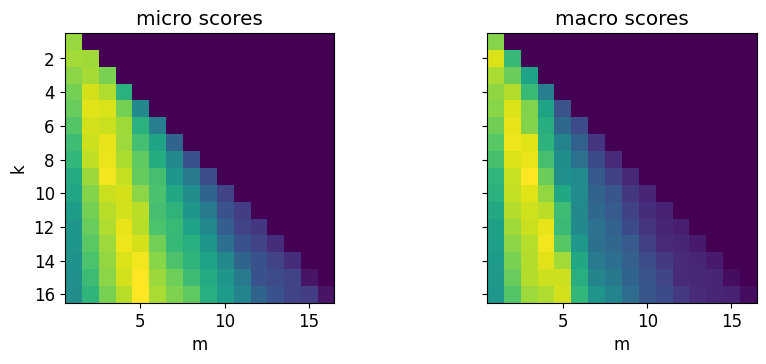

In [66]:
# Para visualizar las matrices perf_micro y perf_macro que acabas de calcular.

fig, (ax0, ax1) = plt.subplots(1, 2, figsize=(10, 3.5), sharey=True)
ax0.imshow(perf_micro)
ax1.imshow(perf_macro)
# imshow() interpreta una matriz como si fuera una imagen.

ax0.set_title("micro scores")
ax0.set_ylabel("k")
ax1.set_title("macro scores")
for ax in [ax0, ax1]:
    ax.set_xlim([0.5, 17 - 0.5])
    ax.set_ylim([17 - 0.5, 0.5])
    ax.set_xlabel("m")
plt.show()

In [67]:
# Para buscar automáticamente la combinación (k, m) que obtuvo el mayor Micro F1.

k, m = np.unravel_index(perf_micro.argmax(), perf_micro.shape)

# perf_micro ->es una matriz 
# argmax() aquí aplana la matriz y busca el ínidice con el valor máximo de todos los elementos
# Una vez que tenemos el máximo -> necesitamos recuperar la coordenada
# por eso añadimos np.unravel_index(perf_micro.argmax(), perf_micro.shape)
# Con esto -> El índice plano es x. Dime en qué fila y columna de una matriz (x,x) está.
# obeteniendo así el mejor k y el mejor m
print(f"Best k: {k}, best m: {m}")

Best k: 15, best m: 5


Obtenemos el mejor desempeño cuando tomamos 15 vecinos cercanos y luego asignamos las labels que ocurren al menos 5 veces

In [68]:
# hide_output

# Este bloque evalúa el método de clasificación por vecinos sobre embeddings 
# para cada tamaño de entrenamiento, como hicmos con Naive bayes, Zero shot y Naive Bayes + Zero-shot

embs_train.drop_index("embedding") 
# Antes había creado un índice sobre todo embs_train. Ahora lo quitamos
# porque lo haremos por train_slice

# Preparamos el test

test_labels = np.array(embs_test["label_ids"]) 
# etiquetas reales de test
test_queries = np.array(embs_test["embedding"], dtype=np.float32)
# embeddings de los textos de test que se usarán como consultas.

for train_slice in train_slices: # Recorre los distintos tamaños de train -> 8, 16, 32, 64, 128 y todo train
    # Create a FAISS index from training slice 
    embs_train_tmp = embs_train.select(train_slice) # selecciona subconjunto
    embs_train_tmp.add_faiss_index("embedding") # Creamos índice FAISS específico
    # Get best k, m values with validation set
    perf_micro, _ = find_best_k_m(embs_train_tmp, valid_queries, valid_labels)
    # elige k y m usando validación, descartamos perf_macro
    k, m = np.unravel_index(perf_micro.argmax(), perf_micro.shape)
    # obtengo k y m que obtuvo el mayor Micro F1 en validación
    
    # Get predictions on test set
    _, samples = embs_train_tmp.get_nearest_examples_batch("embedding",
                                                           test_queries,
                                                           k=int(k))
    # buscamos vecinos para test, descartando los scores porque sólo
    # interesan los ejemplos recuperados y sus etiquetas
    
    y_pred = np.array([get_sample_preds(s, m) for s in samples])
    # Convertimos las etiquetas de los vecinos en predicciones
    
    
    # Evaluate predictions
    clf_report = classification_report(test_labels, y_pred,
        target_names=mlb.classes_, zero_division=0, output_dict=True,)
    macro_scores["Embedding"].append(clf_report["macro avg"]["f1-score"])
    micro_scores["Embedding"].append(clf_report["micro avg"]["f1-score"])
    # Evaluamos en test
    # Comparamos etiquetas reales del Test vs etiquetas predichas mediante vecinos
    

  0%|          | 0/1 [00:00<?, ?it/s]

  0%|          | 0/1 [00:00<?, ?it/s]

  0%|          | 0/1 [00:00<?, ?it/s]

  0%|          | 0/1 [00:00<?, ?it/s]

  0%|          | 0/1 [00:00<?, ?it/s]

  0%|          | 0/1 [00:00<?, ?it/s]

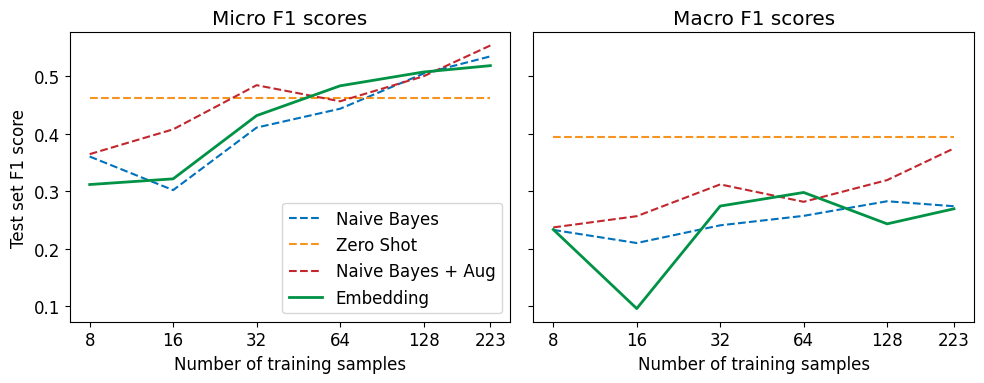

In [69]:
plot_metrics(micro_scores, macro_scores, train_samples, "Embedding")

- Zero-Shot sorprende porque no necesita entrenamiento y mantiene un rendimiento muy competitivo.

- Naive Bayes funciona muy bien cuando hay suficientes ejemplos etiquetados.
Embeddings + k-NN demuestra que los embeddings capturan semántica, pero un simple voto entre vecinos no explota todo su potencial.

### Sidebar: Efficient Similarity Search with FAISS

<img alt="faiss-index" caption="The structure of a FAISS index: the gray points represent data points added to the index, the bold black points are the cluster centers found via k-means clustering, and the colored areas represent the regions belonging to a cluster center" src="images/chapter09_faiss-index.png" id="faiss-index"/>

### End sidebar

### Fine-Tuning a Vanilla Transformer

In [70]:
#hide_output
import torch
from transformers import (AutoTokenizer, AutoConfig,
                          AutoModelForSequenceClassification)
                          
# Cargamos primero el tokenizador 
model_ckpt = "bert-base-uncased"
tokenizer = AutoTokenizer.from_pretrained(model_ckpt)

# Tokenizamos nuestro dataset
def tokenize(batch):
    return tokenizer(batch["text"], truncation=True, max_length=128)

# ds tiene estas columnas:
    # text
    # labels
    # label_ids

ds_enc = ds.map(tokenize, batched=True)
# tras tokenizar, ds_enc tiene las siguientes columnas
    # text
    # labels
    # label_ids
    # input_ids
    # attention_mask
    # token_type_ids

ds_enc = ds_enc.remove_columns(['labels', 'text']) #quitamos las columnas que no necesitamos
# ds_enc. se queda con:
    # label_ids
    # input_ids
    # attention_mask
    # token_type_ids

Map:   0%|          | 0/223 [00:00<?, ? examples/s]

Map:   0%|          | 0/106 [00:00<?, ? examples/s]

Map:   0%|          | 0/111 [00:00<?, ? examples/s]

Map:   0%|          | 0/9303 [00:00<?, ? examples/s]

In [71]:
#hide_output

# La función de pérdida multietiqueta espera las etiquetas como float
# porque calcula una pérdida binaria independiente para cada clase.

# Hugging Face Dataset utiliza internamente Apache Arrow, 
# y Arrow tiene un esquema de tipos para sus columnas.
# Arrow considera label_ids uan columna de enteros -> [1, 0, 1, 0]

# Por eso hay que hacer este arreglo, ya que Arrow ya ha decidido el tipo de la columna existente 
# y cambiar sus elementos uno a uno a otro tipo puede dar problemas.

ds_enc.set_format("torch")
# Para que cuando extraiga elementos del dataset, 
# Hugging Face te los devuelva como tensores de PyTorch. -> tensor([1, 0, 1, 0, 0])

ds_enc = ds_enc.map(lambda x: {"label_ids_f": x["label_ids"].to(torch.float)},
                    remove_columns=["label_ids"])
# creo una columna nueva que infiere de la columna antigua la info y la pasa a float
# Una vez que tenemos la columna antigua con int y la nueva con float, elimino la antigua

ds_enc = ds_enc.rename_column("label_ids_f", "label_ids")
# Recupero el nombre de la columna antigua, pero ahora con formato float



Map:   0%|          | 0/223 [00:00<?, ? examples/s]

Map:   0%|          | 0/106 [00:00<?, ? examples/s]

Map:   0%|          | 0/111 [00:00<?, ? examples/s]

Map:   0%|          | 0/9303 [00:00<?, ? examples/s]

In [72]:
# Aquí se configur cómo se va a entrenar y, sobre todo, 
# cómo va a decidir qué versión del modelo conservar.
# Probablemnete sobreajustaremos rápidamente los datos por su reducido tamaño
# Por eso entrena 20 épocas per no se queda con el último sino con el mejor
# el checkpoint con mayor Micro F1 será el modelo final

from transformers import Trainer, TrainingArguments

training_args_fine_tune = TrainingArguments(
    output_dir="./results", num_train_epochs=20, learning_rate=3e-5,
    lr_scheduler_type='constant', per_device_train_batch_size=4,
    per_device_eval_batch_size=32, weight_decay=0.0, 
    eval_strategy="epoch", save_strategy="epoch",logging_strategy="epoch",
    load_best_model_at_end=True, metric_for_best_model='micro f1',
    save_total_limit=1, log_level='error')

# learning_rate=3e-5 -> Pequeño porque BERT ya está preentrenado,
    # no queremos modificar sus pesos brutalmente
# lr_scheduler_type="constant" -> El learning rate se mantiene constante
# per_device_train_batch_size=4 -> 4 ejemplos → forward → loss → backward → actualizar pesos
# per_device_eval_batch_size=32 -> En evaluación puede utilizar 32 pq no hay backpropagation, 
    # así que consume bastante menos memoria.
# weight_decay=0.0 -> No aplica regularización mediante weight decay
# save_total_limit=1 -> Evita acumular checkpoints. Limita cuántos se mantienen guardados
# log_level="error" -> Reduce la cantidad de mensajes que muestra Transformers.
# eval_strategy="epoch", save_strategy="epoch" -> Cada época: entrenar -> evaluar en validation -> guardar checkpoint


In [73]:
# Dado que el modelo devuelve logits, primero tenemos que normalizar
# las predicciones con sigmoid y poder hacerlas binarias con un simple umbral



from scipy.special import expit as sigmoid

# Aquí están definiendo la función que Trainer utilizará para evaluar el modelo al final 
#de cada época. el "micro f1" lo calculamos aquí

def compute_metrics(pred):
    y_true = pred.label_ids 
    # Son las etiquetas reales
    y_pred = sigmoid(pred.predictions)
    # pred.predictions -> son los logits. El modelo no devuelve 0 y 1's todavía
    # sigmoid -> transforma cada logit a unn valor entre 0 y 1
    # Así podremos interpretarlo como porbbabilidades/scores de cada etiqueta
    # sigmoid en lugar de softmax porque:
        # sigmoid -> cada etiqueta es independiente -> NO suman 1
        # softmax -> todas "compiten" entre sí -> suman 1
    
    y_pred = (y_pred>0.5).astype(float)
    # Para convertir probabilidades en 0 y 1
    # Si es > 0.5 -> True -> en float es 1.
    
    clf_dict = classification_report(y_true, y_pred, target_names=all_labels,
                                     zero_division=0, output_dict=True)
    # Calculamos las métricas y_true vs y_pred
    
    return {"micro f1": clf_dict["micro avg"]["f1-score"],
            "macro f1": clf_dict["macro avg"]["f1-score"]}

In [74]:
#hide_output
# Configuramos BERT para que sepa qué tipo de problema va a resolver, 
# antes de cargar el modelo propiamente dicho.

config = AutoConfig.from_pretrained(model_ckpt)
# cargas la configuración de BERT, no sus pesos. 
# config contiene información como número de capas, tamaño de los hidden states, 
# dropout, vocabulario, etc.
config.num_labels = len(all_labels) 
# Mi problema tiene n etiquetas posibles. 
# Si fueran 8 ->la cabeza de clasificación tendrá 8 salidas

config.problem_type = "multi_label_classification"
# le estoy explictando a Transformers que cada ejemplo pertence simultáneamente 
# a varias etiquetas

In [75]:
# hide_output
for train_slice in train_slices: # recorre los distintos tamaños de train
    model = AutoModelForSequenceClassification.from_pretrained(model_ckpt,
                                                               config=config)
    # Creamos el modelo. 
        # Carga los pesos preentrenados de BERT y 
        # añade/configura la cabeza de clasificación según:
            # config.num_labels
            # config.problem_type
    # Es importante que esto esté dentro del bucle: para cada train_slice empiezas 
    # desde el mismo BERT preentrenado, no desde el modelo ya fine-tuneado en 
    # la iteración anterior.
    # Si reutilizara el mismo modelo, la comparación entre tamaños de entrenamiento 
    # sería injusta.
    
    trainer = Trainer(
        model=model, tokenizer=tokenizer,
        args=training_args_fine_tune,
        compute_metrics=compute_metrics,
        train_dataset=ds_enc["train"].select(train_slice),
        eval_dataset=ds_enc["valid"],)
    # Creamos el trainer

    trainer.train()
    # Entrenamos!!
    # batch -> BERT -> Logits -> BCEWithlogitsLOSS ->backpropagation -> actualizacoón de pesos
    # Durante las 20 épocas va evaluando en valid, y...
    # al final trainer.model queda cargado con el checkpoint que obtuvo el mejor Micro F1 
    # en validación
    
    pred = trainer.predict(ds_enc["test"])
    # usamos ese modelo para predecir sobre test
        # pred.predictions -> logits
        # pred.label_ids -> etiquetas reales
    
    metrics = compute_metrics(pred)
    # Aplico la función de antes:
    # logits-> sigmoid -> porobabilidades ->>0.5 ->prob binaria -> comp vs label_ids reales
    # -> Micro F1 / Macro F1

    macro_scores["Fine-tune (vanilla)"].append(metrics["macro f1"])
    micro_scores["Fine-tune (vanilla)"].append(metrics["micro f1"])
    # guardamos resultados

/tmp/ipykernel_455/3818990943.py:16: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Trainer.__init__`. Use `processing_class` instead.
  trainer = Trainer(


{'loss': 0.6762, 'grad_norm': 12.454251289367676, 'learning_rate': 3e-05, 'epoch': 1.0}
{'eval_loss': 0.618929386138916, 'eval_micro f1': 0.14556962025316456, 'eval_macro f1': 0.10735386135198871, 'eval_runtime': 0.2646, 'eval_samples_per_second': 400.618, 'eval_steps_per_second': 15.118, 'epoch': 1.0}
{'loss': 0.6082, 'grad_norm': 7.5224785804748535, 'learning_rate': 3e-05, 'epoch': 2.0}
{'eval_loss': 0.5796406269073486, 'eval_micro f1': 0.07725321888412018, 'eval_macro f1': 0.04796468294920307, 'eval_runtime': 0.282, 'eval_samples_per_second': 375.824, 'eval_steps_per_second': 14.182, 'epoch': 2.0}
{'loss': 0.5497, 'grad_norm': 2.456902027130127, 'learning_rate': 3e-05, 'epoch': 3.0}
{'eval_loss': 0.5465117692947388, 'eval_micro f1': 0.07692307692307693, 'eval_macro f1': 0.02979829924801462, 'eval_runtime': 0.28, 'eval_samples_per_second': 378.536, 'eval_steps_per_second': 14.284, 'epoch': 3.0}
{'loss': 0.5171, 'grad_norm': 2.360400915145874, 'learning_rate': 3e-05, 'epoch': 4.0}
{'e

/tmp/ipykernel_455/3818990943.py:16: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Trainer.__init__`. Use `processing_class` instead.
  trainer = Trainer(


{'loss': 0.6422, 'grad_norm': 2.170055389404297, 'learning_rate': 3e-05, 'epoch': 1.0}
{'eval_loss': 0.5767545700073242, 'eval_micro f1': 0.15625, 'eval_macro f1': 0.057142857142857134, 'eval_runtime': 0.2919, 'eval_samples_per_second': 363.108, 'eval_steps_per_second': 13.702, 'epoch': 1.0}
{'loss': 0.5622, 'grad_norm': 4.070816516876221, 'learning_rate': 3e-05, 'epoch': 2.0}
{'eval_loss': 0.5318157076835632, 'eval_micro f1': 0.0, 'eval_macro f1': 0.0, 'eval_runtime': 0.297, 'eval_samples_per_second': 356.94, 'eval_steps_per_second': 13.469, 'epoch': 2.0}
{'loss': 0.4855, 'grad_norm': 2.4595234394073486, 'learning_rate': 3e-05, 'epoch': 3.0}
{'eval_loss': 0.4647729694843292, 'eval_micro f1': 0.0, 'eval_macro f1': 0.0, 'eval_runtime': 0.2919, 'eval_samples_per_second': 363.162, 'eval_steps_per_second': 13.704, 'epoch': 3.0}
{'loss': 0.4311, 'grad_norm': 2.5780234336853027, 'learning_rate': 3e-05, 'epoch': 4.0}
{'eval_loss': 0.43435540795326233, 'eval_micro f1': 0.0, 'eval_macro f1': 0.

/tmp/ipykernel_455/3818990943.py:16: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Trainer.__init__`. Use `processing_class` instead.
  trainer = Trainer(


...

{'loss': 0.5616, 'grad_norm': 1.8637887239456177, 'learning_rate': 3e-05, 'epoch': 1.0}
{'eval_loss': 0.46510156989097595, 'eval_micro f1': 0.0, 'eval_macro f1': 0.0, 'eval_runtime': 0.2935, 'eval_samples_per_second': 361.215, 'eval_steps_per_second': 13.631, 'epoch': 1.0}
{'loss': 0.3995, 'grad_norm': 0.9376115202903748, 'learning_rate': 3e-05, 'epoch': 2.0}
{'eval_loss': 0.3738722801208496, 'eval_micro f1': 0.0, 'eval_macro f1': 0.0, 'eval_runtime': 0.2766, 'eval_samples_per_second': 383.211, 'eval_steps_per_second': 14.461, 'epoch': 2.0}
{'loss': 0.3464, 'grad_norm': 1.2726340293884277, 'learning_rate': 3e-05, 'epoch': 3.0}
{'eval_loss': 0.359652578830719, 'eval_micro f1': 0.0, 'eval_macro f1': 0.0, 'eval_runtime': 0.2939, 'eval_samples_per_second': 360.662, 'eval_steps_per_second': 13.61, 'epoch': 3.0}
{'loss': 0.3261, 'grad_norm': 1.3578075170516968, 'learning_rate': 3e-05, 'epoch': 4.0}
{'eval_loss': 0.3467566967010498, 'eval_micro f1': 0.0, 'eval_macro f1': 0.0, 'eval_runtime': 

/tmp/ipykernel_455/3818990943.py:16: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Trainer.__init__`. Use `processing_class` instead.
  trainer = Trainer(


{'loss': 0.4766, 'grad_norm': 1.933078408241272, 'learning_rate': 3e-05, 'epoch': 1.0}
{'eval_loss': 0.37814927101135254, 'eval_micro f1': 0.0, 'eval_macro f1': 0.0, 'eval_runtime': 0.2936, 'eval_samples_per_second': 360.985, 'eval_steps_per_second': 13.622, 'epoch': 1.0}
{'loss': 0.3511, 'grad_norm': 1.259580373764038, 'learning_rate': 3e-05, 'epoch': 2.0}
{'eval_loss': 0.34788474440574646, 'eval_micro f1': 0.032520325203252036, 'eval_macro f1': 0.016460905349794237, 'eval_runtime': 0.2828, 'eval_samples_per_second': 374.886, 'eval_steps_per_second': 14.147, 'epoch': 2.0}
{'loss': 0.3241, 'grad_norm': 1.7794269323349, 'learning_rate': 3e-05, 'epoch': 3.0}
{'eval_loss': 0.32487040758132935, 'eval_micro f1': 0.30344827586206896, 'eval_macro f1': 0.1140096618357488, 'eval_runtime': 0.3, 'eval_samples_per_second': 353.289, 'eval_steps_per_second': 13.332, 'epoch': 3.0}
{'loss': 0.2972, 'grad_norm': 1.207792043685913, 'learning_rate': 3e-05, 'epoch': 4.0}
{'eval_loss': 0.30988040566444397,

/tmp/ipykernel_455/3818990943.py:16: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Trainer.__init__`. Use `processing_class` instead.
  trainer = Trainer(


{'loss': 0.435, 'grad_norm': 0.9959604144096375, 'learning_rate': 3e-05, 'epoch': 1.0}
{'eval_loss': 0.35228094458580017, 'eval_micro f1': 0.0, 'eval_macro f1': 0.0, 'eval_runtime': 0.2821, 'eval_samples_per_second': 375.744, 'eval_steps_per_second': 14.179, 'epoch': 1.0}
{'loss': 0.3294, 'grad_norm': 1.2635964155197144, 'learning_rate': 3e-05, 'epoch': 2.0}
{'eval_loss': 0.3155241906642914, 'eval_micro f1': 0.33783783783783783, 'eval_macro f1': 0.12589605734767026, 'eval_runtime': 0.2984, 'eval_samples_per_second': 355.217, 'eval_steps_per_second': 13.404, 'epoch': 2.0}
{'loss': 0.2909, 'grad_norm': 1.1362195014953613, 'learning_rate': 3e-05, 'epoch': 3.0}
{'eval_loss': 0.29051950573921204, 'eval_micro f1': 0.31724137931034485, 'eval_macro f1': 0.11461645063992826, 'eval_runtime': 0.2836, 'eval_samples_per_second': 373.801, 'eval_steps_per_second': 14.106, 'epoch': 3.0}
{'loss': 0.2462, 'grad_norm': 1.4432181119918823, 'learning_rate': 3e-05, 'epoch': 4.0}
{'eval_loss': 0.259131878614

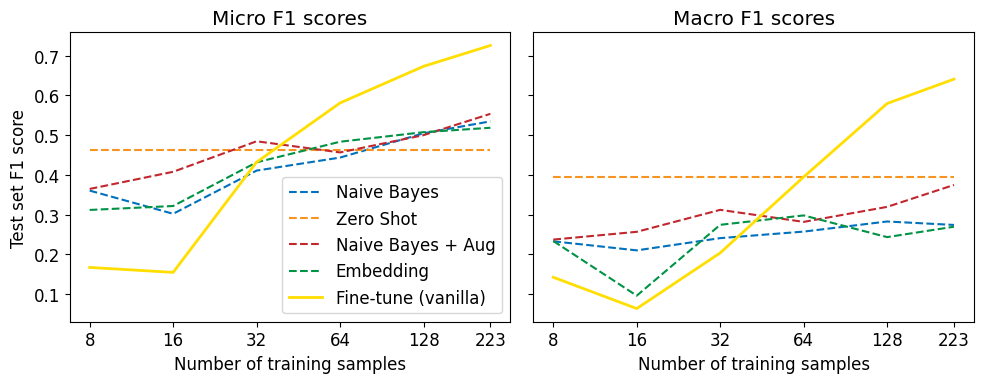

In [76]:
plot_metrics(micro_scores, macro_scores, train_samples, "Fine-tune (vanilla)")

## ¿Por qué introducir el fine-tuning?

La curva amarilla muestra claramente por qué el libro introduce el **fine-tuning**.

### Micro F1

Con pocos datos, el *vanilla fine-tuning* es incluso peor:

- **8 ejemplos** → Micro F1 ≈ **0.17**
- **16 ejemplos** → ≈ **0.15**
- **32 ejemplos** → ≈ **0.43**

Pero cuando se proporcionan suficientes ejemplos:

- **64 ejemplos** → ≈ **0.58**
- **128 ejemplos** → ≈ **0.64**
- **223 ejemplos** → ≈ **0.70**

```text
Pocos datos
    │
    ▼
Fine-tuning poco efectivo
    │
    ▼
Aumentan los datos etiquetados
    │
    ▼
El modelo puede adaptar sus representaciones
    │
    ▼
Gran mejora del rendimiento
```

---

## Macro F1

En **Macro F1** la diferencia es todavía más espectacular.

El *fine-tuning* termina aproximadamente en:

```text
Macro F1 ≈ 0.64
```

mientras que los demás métodos permanecen por debajo de:

```text
Macro F1 < 0.40
```

Esto es especialmente importante porque **Macro F1 da el mismo peso a todas las etiquetas**, independientemente de su frecuencia.

Por tanto, el aumento de Macro F1 indica que el modelo no solo mejora en las etiquetas frecuentes, sino que también **aprende mucho mejor las etiquetas menos frecuentes**.

```text
Fine-tuning
     │
     ├── Mejora etiquetas frecuentes
     │
     └── Mejora etiquetas poco frecuentes
                  │
                  ▼
          Macro F1 aumenta
```

---

## El *trade-off*

La gráfica muestra muy bien el *trade-off* que quiere enseñar esta sección:

> **Con poquísimos datos etiquetados, fine-tunear un Transformer grande puede ser una mala idea. Pero, cuando hay suficientes datos, adaptar sus representaciones a la tarea supera claramente el uso del Transformer como simple extractor de embeddings.**

Conceptualmente:

```text
Transformer preentrenado
          │
          ├──────────────────────────┐
          │                          │
          ▼                          ▼
Feature Extraction              Fine-tuning
          │                          │
Transformer congelado       Transformer entrenable
          │                          │
Embeddings genéricos        Representaciones adaptadas
          │                    a la nueva tarea
          │                          │
          ▼                          ▼
Mejor con muy pocos         Mejor cuando existen
datos etiquetados           suficientes ejemplos
```

### In-Context and Few-Shot Learning with Prompts

In [78]:
prompt = """\
Translate English to French:
thanks =>
"""

## Leveraging Unlabeled Data

### Fine-Tuning a Language Model

In [79]:
# Para seguir entrenando BERT con textos de nuestro dominio,
# Queremos hacer MLM (Mask Language Modelling)

# Primero Tokenizamos

#hide_output
def tokenize(batch):
    return tokenizer(batch["text"], truncation=True,
                     max_length=128, return_special_tokens_mask=True)
# return_special_tokens_mask=True -> Devuelve una máscara adicional que identifica
# los tokens especiales
# el tokenizer genera:
    # input_ids
    # attention_mask -> Te identifica lo que no es [PAD]
    # special_tokens_mask -> identifica las posiciones de los special tokens

ds_mlm = ds.map(tokenize, batched=True) 
# aplicamos las función a nuestra dataset -> añade columnas resultantes de la tokenización 
# al dataset original.

ds_mlm = ds_mlm.remove_columns(["labels", "text", "label_ids"])
# elimina todo lo relacionado con la tarea de clasificación anterior.
# Eso tiene mucho sentido porque ahora no necesitas etiquetas humanas: labels y labels_id
# Para seguir entrenando BERT mediante MLM sólo necesito:
# Texto sin etiquetar -> Tokenización -> input_ids, attention_mask, special_tokens_mask


Map:   0%|          | 0/223 [00:00<?, ? examples/s]

Map:   0%|          | 0/106 [00:00<?, ? examples/s]

Map:   0%|          | 0/111 [00:00<?, ? examples/s]

Map:   0%|          | 0/9303 [00:00<?, ? examples/s]

## `special_tokens_mask` vs `attention_mask`

```text
            special_tokens_mask    attention_mask

[CLS]              1                    1
palabra            0                    1
palabra            0                    1
[SEP]              1                    1
[PAD]              1                    0
```
- attention_mask -> Para BERT : Ignora el padding durante el procesamiento
- special_token_mask -> Para el Data Collator -> No selecciones[CLS], [SEP], [PAD], etc. como tokens que BERT tenga que reconstruir.
- Quiero permitir:[CLS] BERT [MASK] great [SEP]
- No quiero generar: [MASK] BERT is great [SEP]

In [81]:
# Segundo usamos el Data Collator para MLM que utiliza esa info para crear dinámicamente 
# los [MASK] y las etiquetas necesarias para calcular la loss
# La idea es que no dejas los [MASK] fijos en el dataset. 
# El data_collator los crea dinámicamente cada vez que forma un batch.

from transformers import DataCollatorForLanguageModeling, set_seed

data_collator = DataCollatorForLanguageModeling(tokenizer=tokenizer,
                                                mlm_probability=0.15)
# mlm_probability=0.15 -> aproximadamente el 15% de los tokens candidatos 
# serán seleccionados para la tarea de masked language modeling. 
# ya antes excluímos los tokens especiales con  return_special_tokens_mask=True
# la loss sólo se calculará sobre los tokens seleccionados
# data_collator genera:
    # input_ids modificados para MLM -> [CLS] BERT is [MASK] model [SEP]
    # labels (nuevas, las q quitamos eran de la clasificacion anterior) -100  -100 -100 great -100 -100


In [82]:
# demostración visual de lo que hace el DataCollatorForLanguageModeling.
# simplemente enseña cómo transforma una frase antes de dársela a BERT.

set_seed(3)
data_collator.return_tensors = "np"
# le dice al collator que devuelva arrays de NumPy en vez de tensores de PyTorch. 
# Lo hacen porque luego quieren meter el resultado cómodamente en un DataFrame.

inputs = tokenizer("Transformers are awesome!", return_tensors="np")
outputs = data_collator([{"input_ids": inputs["input_ids"][0]}])

original_input_ids = inputs["input_ids"][0]
masked_input_ids = outputs["input_ids"][0]

pd.DataFrame({
    "Original tokens": tokenizer.convert_ids_to_tokens(original_input_ids),
    "Masked tokens": tokenizer.convert_ids_to_tokens(masked_input_ids),
    "Original input_ids": original_input_ids,
    "Masked input_ids": masked_input_ids,
    "Labels": outputs["labels"][0]}).T

,0,1,2,3,4,5
Original tokens,[CLS],transformers,are,awesome,!,[SEP]
Masked tokens,[CLS],transformers,are,awesome,[MASK],[SEP]
Original input_ids,101,19081,2024,12476,999,102
Masked input_ids,101,19081,2024,12476,103,102
Labels,-100,-100,-100,-100,999,-100


In [84]:
# las entradas con -100 no se tienen en cuenta para el cálculo de la loss

In [85]:
data_collator.return_tensors = "pt"
# Deshace el cambio temporal que hiciste antes-> collato devuelve nuevamente pytorch

In [87]:
#hide_output
# Empezamos con el entrenamiento:

from transformers import AutoModelForMaskedLM
# Hasta ahora usábamos AutoModelForSequenceClassification para clasificación
# Ahora -> otra tarea -> otra cabeza
    # En Clasificación: BERT -> Classification head -> Nº de etiquetas
    # Ahora: BERT ->MLM head -> Vocabulario completo
        # Para cada posición selecionada -> Modelo tiene q decidir qué token de vocabulario
        # debe ir ahí
            # Transformers are [MASK]
            # aprox 30.000 logits
            # awesome -> Mayor logit



training_args = TrainingArguments(
    output_dir = f"{model_ckpt}-issues-128", per_device_train_batch_size=32,
    logging_strategy="epoch", eval_strategy="epoch", save_strategy="no",
    num_train_epochs=16, push_to_hub=True, log_level="error", report_to="none")

trainer = Trainer(
        model=AutoModelForMaskedLM.from_pretrained("bert-base-uncased"),
        tokenizer=tokenizer, args=training_args, data_collator=data_collator,
        train_dataset=ds_mlm["unsup"], eval_dataset=ds_mlm["train"])
# cargamos BERT preentrenado con su cabeza MLM. -> Continuamos su preentrenamiento
# No entrenamosBERT desde cero
# Esto es domain-adaptive pretraining: BERT ya conoce inglés general, 
# pero ahora quieres que se familiarice mejor con textos del dominio concreto.

# train_dataset=ds_mlm["unsup"] -> Usamos la parte sin eiquetar de nuestro dataset
# eval_dataset=ds_mlm["train"] -> ara evaluar cómo va el MLM mientras entrenas sobre unsup.

trainer.train()
# Entrenamos!

/tmp/ipykernel_455/2909285364.py:22: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Trainer.__init__`. Use `processing_class` instead.
  trainer = Trainer(


{'loss': 2.1034, 'grad_norm': 6.272395133972168, 'learning_rate': 4.688573883161512e-05, 'epoch': 1.0}
{'eval_loss': 1.6900345087051392, 'eval_runtime': 0.9087, 'eval_samples_per_second': 245.398, 'eval_steps_per_second': 30.812, 'epoch': 1.0}
{'loss': 1.633, 'grad_norm': 6.761737823486328, 'learning_rate': 4.3760738831615125e-05, 'epoch': 2.0}
{'eval_loss': 1.506405234336853, 'eval_runtime': 0.8257, 'eval_samples_per_second': 270.058, 'eval_steps_per_second': 33.909, 'epoch': 2.0}
{'loss': 1.4987, 'grad_norm': 5.315678119659424, 'learning_rate': 4.063573883161512e-05, 'epoch': 3.0}
{'eval_loss': 1.3561336994171143, 'eval_runtime': 0.8517, 'eval_samples_per_second': 261.84, 'eval_steps_per_second': 32.877, 'epoch': 3.0}
{'loss': 1.3959, 'grad_norm': 5.334254741668701, 'learning_rate': 3.751073883161512e-05, 'epoch': 4.0}
{'eval_loss': 1.3318719863891602, 'eval_runtime': 0.9208, 'eval_samples_per_second': 242.183, 'eval_steps_per_second': 30.409, 'epoch': 4.0}
{'loss': 1.3338, 'grad_nor

TrainOutput(global_step=4656, training_loss=1.2833587672702225, metrics={'train_runtime': 1629.7758, 'train_samples_per_second': 91.33, 'train_steps_per_second': 2.857, 'train_loss': 1.2833587672702225, 'epoch': 16.0})

In [88]:
# hide_output
trainer.push_to_hub("Training complete!")

model.safetensors:   0%|          | 0.00/438M [00:00<?, ?B/s]

training_args.bin:   0%|          | 0.00/5.78k [00:00<?, ?B/s]

Upload 2 LFS files:   0%|          | 0/2 [00:00<?, ?it/s]

CommitInfo(commit_url='https://huggingface.co/srmjfba/bert-base-uncased-issues-128/commit/0e0902ce67a199eb72e1bb86ea44a017acb20138', commit_message='Training complete!', commit_description='', oid='0e0902ce67a199eb72e1bb86ea44a017acb20138', pr_url=None, repo_url=RepoUrl('https://huggingface.co/srmjfba/bert-base-uncased-issues-128', endpoint='https://huggingface.co', repo_type='model', repo_id='srmjfba/bert-base-uncased-issues-128'), pr_revision=None, pr_num=None)

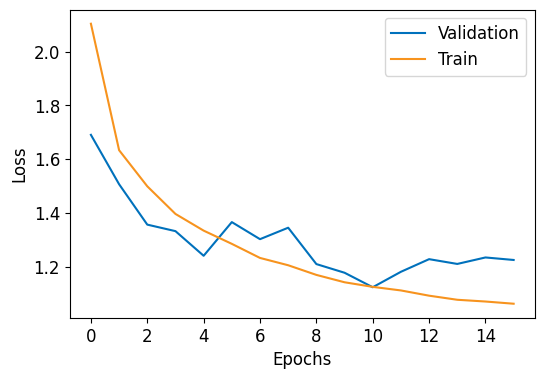

In [89]:
# Sacamos del trainer el historial el entrenamiento y dibujamos las curvas de loss 
# de train y validation.

df_log = pd.DataFrame(trainer.state.log_history)
# Trainer ha ido guardando durante trainer.train() un historial en:
# trainer.state.log_history. Da algo como
    # {'loss': 2.1034, 'epoch': 1.0, ...}
    # {'eval_loss': 1.6900, 'epoch': 1.0, ...}
    # {'loss': 1.6330, 'epoch': 2.0, ...}
    # {'eval_loss': 1.5064, 'epoch': 2.0, ...}
# Lo convertimos en Dataframe

(df_log.dropna(subset=["eval_loss"]).reset_index()["eval_loss"]
 .plot(label="Validation"))
# df_log.dropna(subset=["eval_loss"]) -> Se queda solo con las filas donde existe eval_loss
# Como sólo nos quedamos con unas filas, pero conservan los índices originales
# reset_index() -> queda con índice nuevo

df_log.dropna(subset=["loss"]).reset_index()["loss"].plot(label="Train")
#  Se queda solo con las filas donde existe loss
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend(loc="upper right")
plt.show()

### Fine-Tuning a Classifier

In [90]:
#hide_output

# Aquí hacemos el paso final de la domain adaptation: cogen el BERT que acabo de 
# seguir preentrenando con MLM sobre los issues y ahora lo fine-tunean para clasificación 
# multietiqueta.

# Con vanilla fine-tuning: bert-base-uncased -> fine-tuning clasificación
# Ahora -> bert-base-uncased -> MLM sobre issues -> bert-base-uncased-issues-128 ->
# -> fine-tuning clasificación 

model_ckpt = f'{model_ckpt}-issues-128' 
# el checkpoint apunta: aldominio que acabo de entrenar
config = AutoConfig.from_pretrained(model_ckpt)
config.num_labels = len(all_labels)
config.problem_type = "multi_label_classification"
# vuelvo a preparar la configuración para clasificación multietiqueta, 
# exactamente igual que antes.

for train_slice in train_slices: # experimento para distintos tamaños de datos etiquetados
    model = AutoModelForSequenceClassification.from_pretrained(model_ckpt,
                                                               config=config)
    # crea un clasificador nuevo, pero partiendo ahora del BERT adaptado al dominio, 
    # no del BERT original.
    trainer = Trainer(
        model=model,
        tokenizer=tokenizer,
        args=training_args_fine_tune,
        compute_metrics=compute_metrics,
        train_dataset=ds_enc["train"].select(train_slice),
        eval_dataset=ds_enc["valid"],
    )

    trainer.train() # entrenamos
    pred = trainer.predict(ds_enc['test']) # predecimos a partir de test
    metrics = compute_metrics(pred) # generamos métricas
    # DA refers to domain adaptation
    macro_scores['Fine-tune (DA)'].append(metrics['macro f1'])
    micro_scores['Fine-tune (DA)'].append(metrics['micro f1'])
    # Guardamos resultados nuevos

/tmp/ipykernel_455/2348059469.py:10: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Trainer.__init__`. Use `processing_class` instead.
  trainer = Trainer(


{'loss': 0.6413, 'grad_norm': 1.9553673267364502, 'learning_rate': 3e-05, 'epoch': 1.0}
{'eval_loss': 0.5617804527282715, 'eval_micro f1': 0.031746031746031744, 'eval_macro f1': 0.013888888888888888, 'eval_runtime': 0.2826, 'eval_samples_per_second': 375.109, 'eval_steps_per_second': 14.155, 'epoch': 1.0}
{'loss': 0.5049, 'grad_norm': 1.710877776145935, 'learning_rate': 3e-05, 'epoch': 2.0}
{'eval_loss': 0.48382192850112915, 'eval_micro f1': 0.0, 'eval_macro f1': 0.0, 'eval_runtime': 0.2809, 'eval_samples_per_second': 377.354, 'eval_steps_per_second': 14.24, 'epoch': 2.0}
{'loss': 0.4334, 'grad_norm': 1.3979376554489136, 'learning_rate': 3e-05, 'epoch': 3.0}
{'eval_loss': 0.43869486451148987, 'eval_micro f1': 0.0, 'eval_macro f1': 0.0, 'eval_runtime': 0.2751, 'eval_samples_per_second': 385.269, 'eval_steps_per_second': 14.538, 'epoch': 3.0}
{'loss': 0.3895, 'grad_norm': 1.2710278034210205, 'learning_rate': 3e-05, 'epoch': 4.0}
{'eval_loss': 0.41284143924713135, 'eval_micro f1': 0.0, 'e

/tmp/ipykernel_455/2348059469.py:10: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Trainer.__init__`. Use `processing_class` instead.
  trainer = Trainer(


{'loss': 0.6572, 'grad_norm': 1.5791453123092651, 'learning_rate': 3e-05, 'epoch': 1.0}
{'eval_loss': 0.5496045351028442, 'eval_micro f1': 0.12949640287769784, 'eval_macro f1': 0.044444444444444446, 'eval_runtime': 0.2585, 'eval_samples_per_second': 410.092, 'eval_steps_per_second': 15.475, 'epoch': 1.0}
{'loss': 0.4719, 'grad_norm': 1.3404152393341064, 'learning_rate': 3e-05, 'epoch': 2.0}
{'eval_loss': 0.4453088641166687, 'eval_micro f1': 0.0, 'eval_macro f1': 0.0, 'eval_runtime': 0.2901, 'eval_samples_per_second': 365.36, 'eval_steps_per_second': 13.787, 'epoch': 2.0}
{'loss': 0.3919, 'grad_norm': 1.295039415359497, 'learning_rate': 3e-05, 'epoch': 3.0}
{'eval_loss': 0.39865297079086304, 'eval_micro f1': 0.0, 'eval_macro f1': 0.0, 'eval_runtime': 0.2846, 'eval_samples_per_second': 372.423, 'eval_steps_per_second': 14.054, 'epoch': 3.0}
{'loss': 0.3525, 'grad_norm': 1.0716803073883057, 'learning_rate': 3e-05, 'epoch': 4.0}
{'eval_loss': 0.37560325860977173, 'eval_micro f1': 0.0, 'eva

/tmp/ipykernel_455/2348059469.py:10: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Trainer.__init__`. Use `processing_class` instead.
  trainer = Trainer(


...

{'loss': 0.5148, 'grad_norm': 0.955431342124939, 'learning_rate': 3e-05, 'epoch': 1.0}
{'eval_loss': 0.3877880871295929, 'eval_micro f1': 0.0, 'eval_macro f1': 0.0, 'eval_runtime': 0.2721, 'eval_samples_per_second': 389.583, 'eval_steps_per_second': 14.701, 'epoch': 1.0}
{'loss': 0.3562, 'grad_norm': 0.7320446968078613, 'learning_rate': 3e-05, 'epoch': 2.0}
{'eval_loss': 0.35309308767318726, 'eval_micro f1': 0.0, 'eval_macro f1': 0.0, 'eval_runtime': 0.2763, 'eval_samples_per_second': 383.683, 'eval_steps_per_second': 14.479, 'epoch': 2.0}
{'loss': 0.322, 'grad_norm': 0.7816152572631836, 'learning_rate': 3e-05, 'epoch': 3.0}
{'eval_loss': 0.3280482292175293, 'eval_micro f1': 0.08, 'eval_macro f1': 0.039316239316239315, 'eval_runtime': 0.2636, 'eval_samples_per_second': 402.108, 'eval_steps_per_second': 15.174, 'epoch': 3.0}
{'loss': 0.2837, 'grad_norm': 1.369697093963623, 'learning_rate': 3e-05, 'epoch': 4.0}
{'eval_loss': 0.3098057806491852, 'eval_micro f1': 0.3841059602649007, 'eval_

/tmp/ipykernel_455/2348059469.py:10: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Trainer.__init__`. Use `processing_class` instead.
  trainer = Trainer(


{'loss': 0.4389, 'grad_norm': 1.2330267429351807, 'learning_rate': 3e-05, 'epoch': 1.0}
{'eval_loss': 0.36132675409317017, 'eval_micro f1': 0.0, 'eval_macro f1': 0.0, 'eval_runtime': 0.2967, 'eval_samples_per_second': 357.209, 'eval_steps_per_second': 13.48, 'epoch': 1.0}
{'loss': 0.3306, 'grad_norm': 1.0873396396636963, 'learning_rate': 3e-05, 'epoch': 2.0}
{'eval_loss': 0.3177030682563782, 'eval_micro f1': 0.23529411764705882, 'eval_macro f1': 0.08888888888888889, 'eval_runtime': 0.2831, 'eval_samples_per_second': 374.473, 'eval_steps_per_second': 14.131, 'epoch': 2.0}
{'loss': 0.2848, 'grad_norm': 1.7174333333969116, 'learning_rate': 3e-05, 'epoch': 3.0}
{'eval_loss': 0.28120824694633484, 'eval_micro f1': 0.48484848484848486, 'eval_macro f1': 0.18507261060452548, 'eval_runtime': 0.2582, 'eval_samples_per_second': 410.528, 'eval_steps_per_second': 15.492, 'epoch': 3.0}
{'loss': 0.2343, 'grad_norm': 0.9028297066688538, 'learning_rate': 3e-05, 'epoch': 4.0}
{'eval_loss': 0.245469212532

/tmp/ipykernel_455/2348059469.py:10: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Trainer.__init__`. Use `processing_class` instead.
  trainer = Trainer(


{'loss': 0.408, 'grad_norm': 0.8023220896720886, 'learning_rate': 3e-05, 'epoch': 1.0}
{'eval_loss': 0.33901476860046387, 'eval_micro f1': 0.15384615384615385, 'eval_macro f1': 0.06535947712418301, 'eval_runtime': 0.2871, 'eval_samples_per_second': 369.161, 'eval_steps_per_second': 13.931, 'epoch': 1.0}
{'loss': 0.3017, 'grad_norm': 0.9563238620758057, 'learning_rate': 3e-05, 'epoch': 2.0}
{'eval_loss': 0.26878708600997925, 'eval_micro f1': 0.4875, 'eval_macro f1': 0.19055287171229202, 'eval_runtime': 0.2645, 'eval_samples_per_second': 400.736, 'eval_steps_per_second': 15.122, 'epoch': 2.0}
{'loss': 0.2361, 'grad_norm': 0.7271828651428223, 'learning_rate': 3e-05, 'epoch': 3.0}
{'eval_loss': 0.21971935033798218, 'eval_micro f1': 0.5780346820809249, 'eval_macro f1': 0.2884987328264639, 'eval_runtime': 0.2929, 'eval_samples_per_second': 361.941, 'eval_steps_per_second': 13.658, 'epoch': 3.0}
{'loss': 0.1725, 'grad_norm': 1.9071872234344482, 'learning_rate': 3e-05, 'epoch': 4.0}
{'eval_los

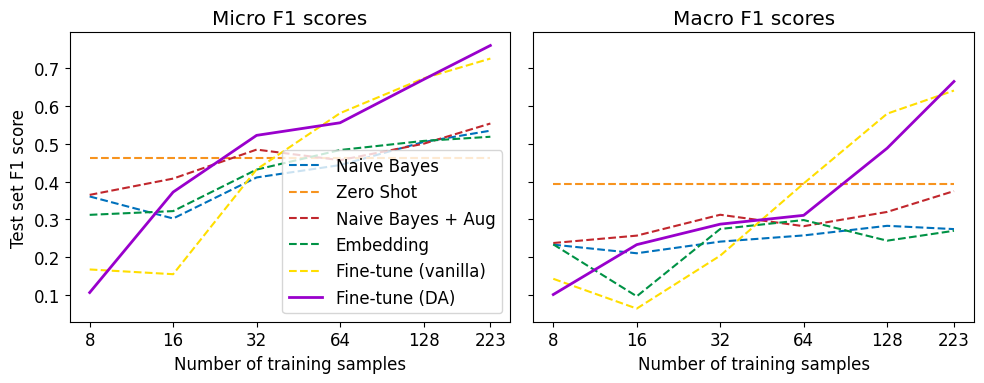

In [91]:
plot_metrics(micro_scores, macro_scores, train_samples, "Fine-tune (DA)")

### Advanced Methods

#### Unsupervised data augmentation

<img alt="uda" width="600" caption="Training a model M with UDA (courtesy of Qizhe Xie)" src="images/chapter09_uda.png" id="uda"/>    

#### Uncertainty-aware self-training

<img alt="ust" width="600" caption="The UST method consists of a teacher that generates pseudo-labels and a student that is subsequently trained on those labels; after the student is trained it becomes the teacher and the step is repeated (courtesy of Subhabrata Mukherjee)footnote:[S. Mukherjee and A.H. Awadallah, ["Uncertainty-Aware Self-Training for Few-Shot Text Classification"](https://arxiv.org/abs/2006.15315), (2020).]" src="images/chapter09_ust.png" id="ust"/>

## Conclusion